# Exact Diagonalization

Exact diagonalization is a numerical method that involves directly solving for the eigenvalues and eigenvectors of the Hamiltonian. In this instance, we will use this method to understand the $k$ interaction by turning off the the $J$ and $h$ parameters:

$$ \mathcal{H_k} = \sum_i k_R(\sigma_i^x \sigma_{i+2}^y- \sigma_i^z\sigma_{i+1}^y\sigma_{i+2}^x)+k_L(\sigma_i^x\sigma_{i+1}^y\sigma_{i+2}^z - \sigma_{i}^y\sigma_{i+2}^x) $$

P.S. Do NOT use odd system sizes, everything breaks because of the way that the polarized boundary conditions work.

# ED Implementation using QuSpin

## Reset Simulation

In [ ]:
shutil.rmtree(f"ed_results/L{L}_{opp}{set}_{scan_var}{np.min(values)}-{np.max(values)}_states")
shutil.rmtree(f"ed_results/L{L}_{opp}{set}_{scan_var}{np.min(values)}-{np.max(values)}_values")
shutil.rmtree(f"ed_results/L{L}_{opp}{set}_{scan_var}{np.min(values)}-{np.max(values)}_states_dual")
shutil.rmtree(f"ed_results/L{L}_{opp}{set}_{scan_var}{np.min(values)}-{np.max(values)}_values_dual")

# fetch the file you are studying
gc.collect()

### Check parity code

# op_string = "x" * l

# # coupling list: coefficient + all site indices
# coupling = [[1.0] + list(range(l))]

# P = hamiltonian(
#     [[op_string, coupling]],
#     [],
#     basis=basis_dual,
#     dtype=np.float64
# )
# P_2 = hamiltonian(
#     [['zz', [[1.0, 0, l-1]]]],
#     [],
#     basis=basis,
#     dtype=np.complex128

# )

# parity = P.expt_value(psi0_dual)
# parity2 = P_2.expt_value(psi0)

NameError: name 'L' is not defined

In [ ]:
from quspin.basis import spin_basis_1d
from quspin.operators import hamiltonian, quantum_LinearOperator
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import gc
import os
import shutil

# try breaking different symmetries
L        = 14
J        = 1

start    = 0.8
end      = 1.2
step     = 0.1

scan_var = "h"
values   = np.arange(start, end+step, step)
# values   = [10**i for i in np.arange(0, 2.1, 0.1)]
# values = values[:4]
opp      = "k" if scan_var == "h" else "h"
set      = 0.5

## Exact Diagonalization

In [ ]:
def exact_diagonalization_line(values, scan_var, opp, set, L, dual=False):
    """Perform ED along a parameter line, restricting to even/odd sites to avoid artificial degeneracy"""
    
    if not os.path.exists("ed_results"):
        os.mkdir("ed_results")

    suffix = "_dual" if dual else ""
    folder_eigenstates = f"ed_results/L{L}_{opp}{set}_{scan_var}{np.min(values)}-{np.max(values)}_states{suffix}"
    folder_eigenvalues = f"ed_results/L{L}_{opp}{set}_{scan_var}{np.min(values)}-{np.max(values)}_values{suffix}"

    if not os.path.exists(folder_eigenstates):
        os.mkdir(folder_eigenstates)
        os.mkdir(folder_eigenvalues)
    else:
        return folder_eigenstates

    # select active sites
    start = 1 if dual else 0
    step = 2

    active_sites = list(range(start, L, step))
    L_active = len(active_sites)

    # define a reduced basis for only active sites
    basis = spin_basis_1d(L_active)

    for ind, val in tqdm(enumerate(values), total=len(values)):
        J = 1.0

        # scan variable assignment
        if scan_var == "h":
            h = val
            k_r = set
            k_l = set
        else:
            h = set
            k_r = val
            k_l = val

        # dual transformation
        if dual:
            h = 1/h
            k_r = k_r/h
            k_l = k_l/h

        # map active sites to 0..L_active-1 for QuSpin
        idx_map = {site: i for i, site in enumerate(active_sites)}

        # build Hamiltonian terms
        J_term = [[J, idx_map[i], idx_map[(i+2) % L]] for i in active_sites]
        h_term = [[h, idx_map[i]] for i in active_sites]
        xy_term = [[k_r, idx_map[i], idx_map[(i+4)%L]] for i in active_sites]
        yx_term = [[-k_l, idx_map[i], idx_map[(i+4)%L]] for i in active_sites]
        xyz_term = [[k_l, idx_map[i], idx_map[(i+2)%L],idx_map[(i+4)%L]] for i in active_sites]
        zyx_term = [[-k_r,  idx_map[i], idx_map[(i+2)%L],idx_map[(i+4)%L]] for i in active_sites]
        static = [
            # ["xx", J_term],
            # ["z", h_term],
            ["xy", xy_term],
            ["yx", yx_term],
            ["xyz", xyz_term], 
            ["zyx", zyx_term]
        ]

        # tiny symmetry-breaking field to lift residual degeneracy
        g = 5e-3
        # static.append(["x", [[(-1)**i * g, i] for i in range(L_active)]])
        static.append(['x', [[g, 0]], ])

        print(f"Running for (J,h, kl, kr) = {J}, {h}, {k_l}, {k_r}")
        print(static)

        # construct Hamiltonian
        H = hamiltonian(static, [], basis=basis, dtype=np.complex128, check_symm=False, check_herm=False)
        
        # low-energy eigenvalues
        E, psi = H.eigsh(k=10, which="SA")

        # save results
        np.savetxt(os.path.join(folder_eigenvalues, f"{opp}{scan_var}_{set:.10f}_{val:.10f}_energies"), E)

        # save first few eigenvectors
        n = 1
        for i in range(n):
            psi_temp = psi[:, i]
            np.save(os.path.join(folder_eigenstates, f"{opp}{scan_var}_{set:.10f}_{val:.10f}_state_{i}"), psi_temp)

    return folder_eigenstates

results = exact_diagonalization_line(values=values, scan_var=scan_var, opp=opp, set=set, L=L)
results1 = exact_diagonalization_line(values=values, scan_var=scan_var, opp=opp, set=set, L=L, dual=True)



NameError: name 'values' is not defined

In [2]:
from quspin.basis import spin_basis_1d
from quspin.operators import hamiltonian, quantum_LinearOperator
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import gc
import os
import shutil

def ed_check(k_l, k_r, L, bc="pbc"):
    """Perform ED along a parameter line, restricting to even/odd sites to avoid artificial degeneracy"""

    basis = spin_basis_1d(L)

    J=1
    h=0.5

    # build Hamiltonian terms
    if bc == "pbc":
        J_term = [[J, i, (i+1)% L] for i in range(L)]
        h_term = [[h, i] for i in range(L)]
        xy_term = [[k_r, i, (i+2)%L] for i in range(L)]
        yx_term = [[-k_l, i, (i+2)%L] for i in range(L)]
        xyz_term = [[k_l, i, (i+1)%L, (i+2)%L] for i in range(L)]
        zyx_term = [[-k_r, i, (i+1)%L, (i+2)%L] for i in range(L)]
        static = [
            ["xx", J_term],
            ["z", h_term],
            ["xy", xy_term],
            ["yx", yx_term],
            ["xyz", xyz_term], 
            ["zyx", zyx_term]
        ]
    else:
        J_term = [[J, i, (i+1)] for i in range(L-1)]
        h_term = [[h, i] for i in range(L)]
        xy_term = [[k_r, i, (i+2)] for i in range(L-2)]
        yx_term = [[-k_l, i, (i+2)] for i in range(L-2)]
        xyz_term = [[k_l, i, (i+1), (i+2)] for i in range(L-2)]
        zyx_term = [[-k_r, i, (i+1), (i+2)] for i in range(L-2)]
        static = [
            ["xx", J_term],
            ["z", h_term],
            ["xy", xy_term],
            ["yx", yx_term],
            ["xyz", xyz_term], 
            ["zyx", zyx_term]
        ]

    print(f"Running for (J,h, kl, kr) = {J}, {h}, {k_l}, {k_r}")

    # construct Hamiltonian
    H = hamiltonian(static, [], basis=basis, dtype=np.complex128, check_symm=False, check_herm=False)
    
    # low-energy eigenvalues
    E, psi = H.eigsh(k=20, which="SA")
    indices = np.argsort(E)

    return E[indices], psi[:,indices]

K = np.arange(0, 3.1, 0.1)
energy_gap = []
for i, k in enumerate(K):
    E, psi = ed_check(k, k, 15, bc='obc')
    ground_energy = E[0]
    E -= ground_energy
    energy_gap.append((E[1] - E[0]) / 19)
#     plt.plot(E[1:10]/19, marker='s', label=f"k={k}")
#     plt.xlabel(f"State {i}")
#     plt.ylabel(r"$(E - E_0)/ L$")
# plt.semilogy()
# plt.show()

# plt.figure(figsize=(5, 5))
# E, psi   = ed_check(1, 1, 9)
# E1, psi1 = ed_check(1, 1, 13)
# E2, psi2 = ed_check(1, 1, 17)
# # E3, psi3 = ed_check(1, 1, 18)
# # E4, psi4 = ed_check(1, 1, 20)
# excited_states = np.arange(1, 10)
# plt.plot(excited_states, (E[1:10] - E[0])/9,label="L=9", marker='s')
# plt.plot(excited_states, (E1[1:10] - E1[0])/12,label="L=12", marker='x')
# plt.plot(excited_states, (E2[1:10] - E2[0])/15, label="L=15", marker='o')
# plt.semilogy()
# # plt.plot(E3[:10]/18, label="L=18", marker='P')
# # plt.plot(E4[:10]/21, label="L=20", marker='D')

# plt.xlabel("Excited State i", fontsize=16)
# plt.ylabel(r"$E-E_0/L$", fontsize=16)
# plt.grid()
# plt.legend(fontsize=16)
# plt.show()
# plt.figure(figsize=(5, 5))

# E0, psi0   = ed_check(1, 1, 9,  bc="obc")
# E01, psi01 = ed_check(1, 1, 13, bc='obc')
# E02, psi02 = ed_check(1, 1, 17, bc='obc')
# # E03, psi03 = ed_check(1, 1, 18, bc='obc')
# # E04, psi04 = ed_check(1, 1, 20, bc='obc')


# plt.plot(excited_states, (E0[1:10] - E0[0])/9,label="L=9", marker='s')
# plt.plot(excited_states, (E01[1:10] - E01[0])/12,label="L=12", marker='x')
# plt.plot(excited_states, (E02[1:10] - E02[0])/15, label="L=15", marker='o')
# plt.semilogy()
# # plt.plot(E03[:10]/18, label="L=18", marker='P')
# # plt.plot(E04[:10]/21, label="L=21", marker='D')

# plt.xlabel("Excited State i", fontsize=16)
# plt.ylabel(r"$E-E_0/L$", fontsize=16)
# plt.grid()
# plt.legend(fontsize=16)
# plt.show()


# # what does sigmaX, sigmaY, sigmaZ?

Running for (J,h, kl, kr) = 1, 0.5, 0.0, 0.0
Running for (J,h, kl, kr) = 1, 0.5, 0.1, 0.1
Running for (J,h, kl, kr) = 1, 0.5, 0.2, 0.2
Running for (J,h, kl, kr) = 1, 0.5, 0.30000000000000004, 0.30000000000000004
Running for (J,h, kl, kr) = 1, 0.5, 0.4, 0.4
Running for (J,h, kl, kr) = 1, 0.5, 0.5, 0.5
Running for (J,h, kl, kr) = 1, 0.5, 0.6000000000000001, 0.6000000000000001
Running for (J,h, kl, kr) = 1, 0.5, 0.7000000000000001, 0.7000000000000001
Running for (J,h, kl, kr) = 1, 0.5, 0.8, 0.8
Running for (J,h, kl, kr) = 1, 0.5, 0.9, 0.9
Running for (J,h, kl, kr) = 1, 0.5, 1.0, 1.0
Running for (J,h, kl, kr) = 1, 0.5, 1.1, 1.1
Running for (J,h, kl, kr) = 1, 0.5, 1.2000000000000002, 1.2000000000000002
Running for (J,h, kl, kr) = 1, 0.5, 1.3, 1.3
Running for (J,h, kl, kr) = 1, 0.5, 1.4000000000000001, 1.4000000000000001
Running for (J,h, kl, kr) = 1, 0.5, 1.5, 1.5
Running for (J,h, kl, kr) = 1, 0.5, 1.6, 1.6
Running for (J,h, kl, kr) = 1, 0.5, 1.7000000000000002, 1.7000000000000002
Running 

In [1]:
plt.plot(energy_gap)

NameError: name 'plt' is not defined

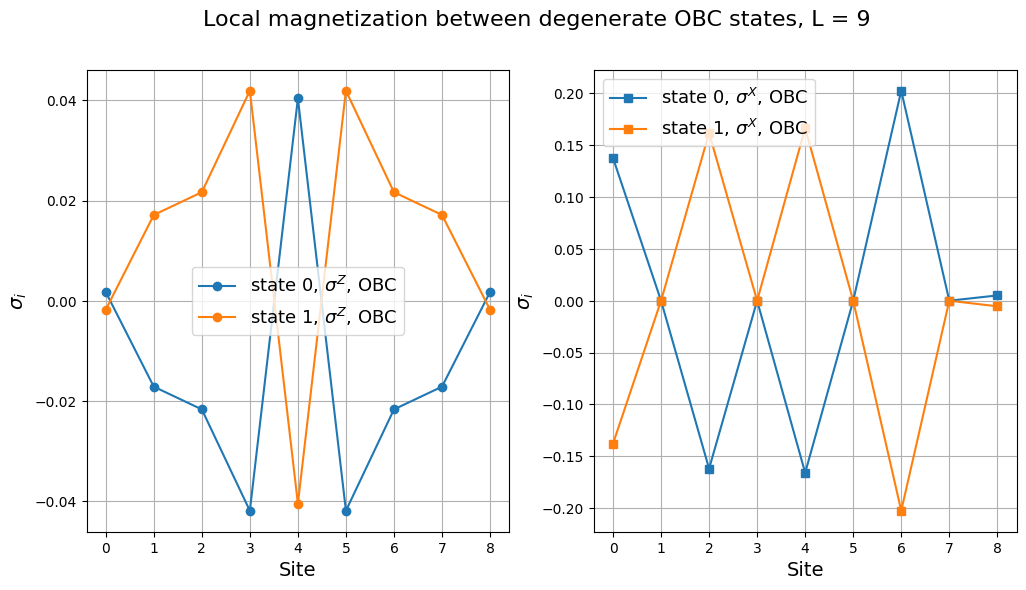

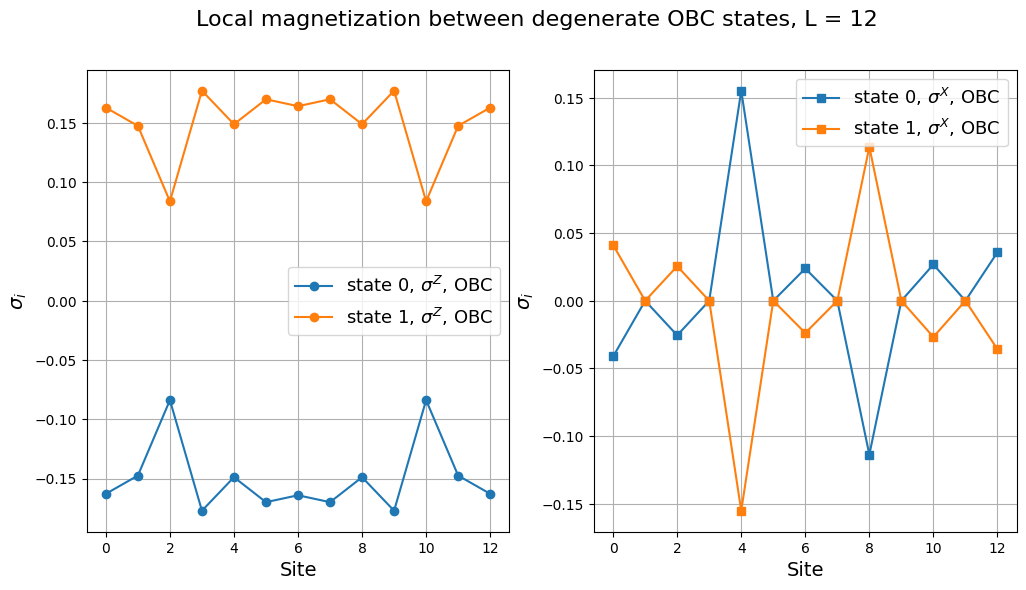

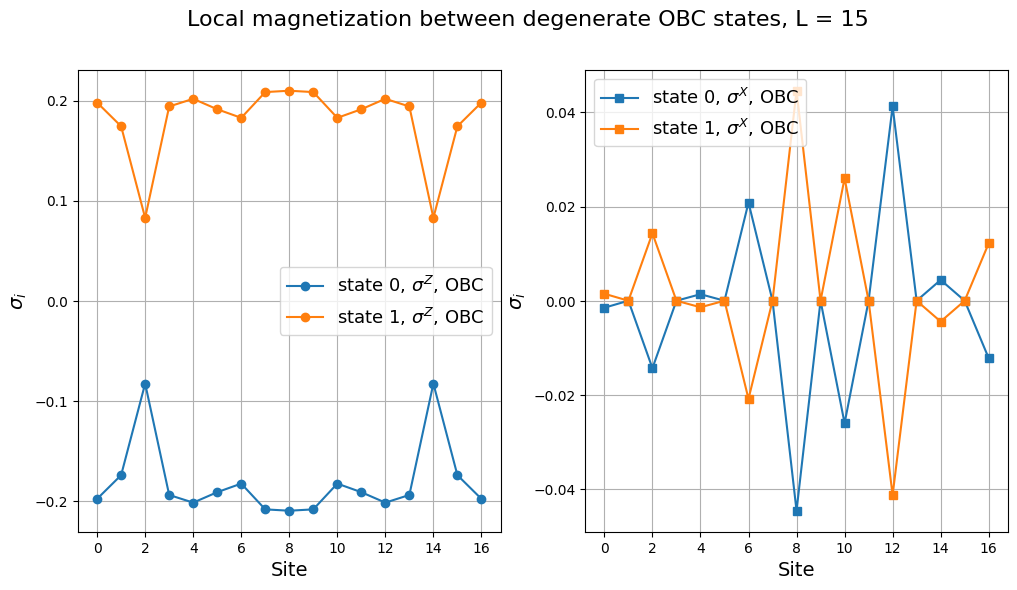

In [20]:
def magnetization_string(op, psi, dist=1, bc='pbc'):
    """
    Measure <op_i op_{i+dist} ...> on even (regular) or odd (dual) sites.
    The basis is inferred from the size of psi.
    """

    # infer active lattice size
    L = int(np.log2(psi.size))
    basis = spin_basis_1d(L)



    n_ops = len(op)
    values = []

    if bc == 'pbc':
        for i in range(L):
            indices = [(i + j*dist) % L for j in range(n_ops)]

            static = [
                [op, [[1.0, *indices]]]
            ]
            operator = quantum_LinearOperator(
                static,
                basis=basis,
                check_symm=False,
                check_herm=False,
                dtype=np.complex128,
            )

            val = operator.expt_value(psi)
            values.append(np.real(val))
    else:
        for i in range(L-(dist*(n_ops-1))):
            indices = [i + j*dist for j in range(n_ops)]
            static = [
                [op, [[1.0, *indices]]]
            ]
            operator = quantum_LinearOperator(
                static,
                basis=basis,
                check_symm=False,
                check_herm=False,
                dtype=np.complex128,
            )

            val = operator.expt_value(psi)
            values.append(np.real(val))
    return np.array(values)

psi_check = [psi, psi1, psi2]
psi_check1 = [psi0, psi01, psi02]
L = [9,12, 15]
for j in range(3):
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))
    for i in range(2):
        # X = magnetization_string('xy', psi_check1[j][:,i], dist=2)
        # Y = magnetization_string('yx', psi_check1[j][:,i], dist=2)
        # XX = magnetization_string('xyz', psi_check1[j][:,i])
        # YY = magnetization_string('zyx', psi_check1[j][:,i])
        sigma1 = magnetization_string('x', psi_check1[j][:,i])
        sigma = magnetization_string('z', psi_check1[j][:,i])


        # plt.plot(X-Y+XX-YY, marker='s',label=f"state {i} xiy-yix")
        ax[0].plot(sigma, marker='o', label=f'state {i}, ' +r"$\sigma^Z$"+', OBC')
        ax[1].plot(sigma1, marker='s', label=f'state {i}, ' +r"$\sigma^X$"+', OBC')
    ax[0].legend(fontsize=13)
    ax[0].set_xlabel("Site", fontsize=14)
    ax[0].set_ylabel(r"$\sigma_i$", fontsize=14)
    ax[1].legend(fontsize=13)
    ax[1].set_xlabel("Site", fontsize=14)
    ax[1].set_ylabel(r"$\sigma_i$", fontsize=14)
    ax[0].grid()
    ax[1].grid()
    plt.suptitle(f"Local magnetization between degenerate OBC states, L = {L[j]}", fontsize=16)
    plt.show()

## Energy Profile

/home/silvanita/Desktop/thesis/master_thesis/books/ed_results/L28_k0.5_h0.8-1.2_values
kh_0.5000000000_0.8000000000_energies


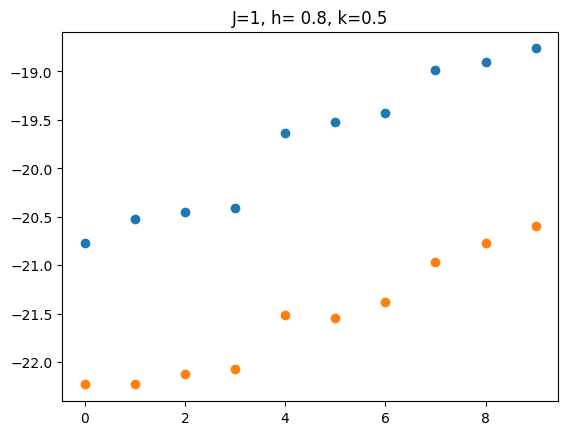

kh_0.5000000000_0.9000000000_energies


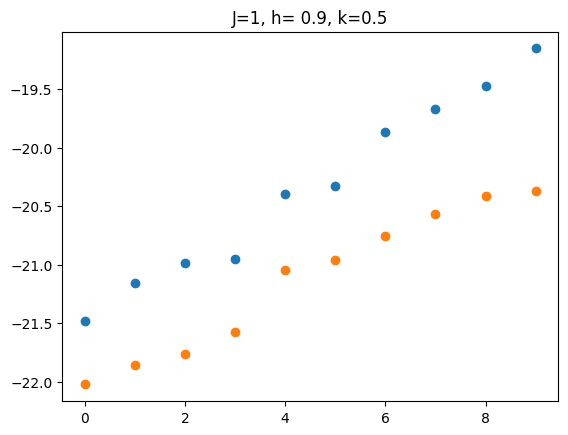

kh_0.5000000000_1.0000000000_energies


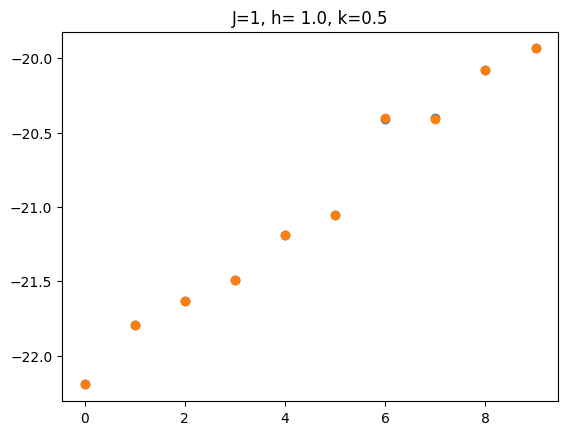

kh_0.5000000000_1.1000000000_energies


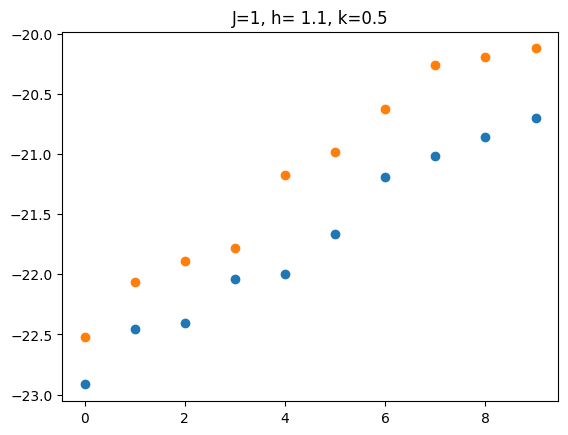

kh_0.5000000000_1.2000000000_energies


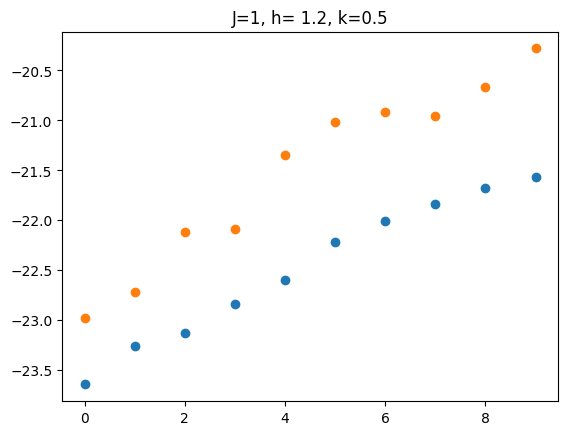

In [ ]:
# plot energy spectrum
results = f"ed_results/L{L}_{opp}{set}_{scan_var}{np.min(values)}-{np.max(values)}_states"
loc = os.path.join(os.getcwd(), f"ed_results/L{L}_{opp}{set}_{scan_var}{np.min(values)}-{np.max(values)}_values")
print(loc)

gs_energy = []
for (i, v) in zip(sorted(os.listdir(loc), key=lambda x: float(x.split('_')[2])), values):
    print(i)
    energy = np.loadtxt(os.path.join(loc, i))
    energy_dual = np.loadtxt(os.path.join(loc+"_dual", i))
    # energy = sorted(energy)
    plt.scatter(range(len(energy)), energy)
    plt.scatter(range(len(energy_dual)), energy_dual)
    gs_energy.append(energy[0])
    plt.title(f"J={J}, {scan_var}= {v}, {opp}={set}")
    plt.show()


## Topological Phases

What we are trying to look for is the existence of strong zero modes in our system. Maybe it is there, maybe it is not. We do this by noting that in the presence of SZM, we have the expected scaling for the parity gap:
$$ \Delta_p = | E_{even} - E_{odd}| \propto \exp{(-\frac{N}{\xi_{zm}})}$$
for some zero mode correlation length $\xi_{zm}$

In [ ]:
def exact_diagonalization_parity(L, params, dual=False):
    """Perform ED along a parameter line, restricting to even/odd sites to avoid artificial degeneracy"""

    active_sites = list(range(L))

    # define a reduced basis for only active sites
    basis_even = spin_basis_1d(int(L), zblock=+1)
    basis_odd = spin_basis_1d(int(L), zblock=-1)
    J, h, k = params

    # map active sites to 0..L_active-1 for QuSpin
    idx_map = {site: i for i, site in enumerate(active_sites)}

    # build Hamiltonian terms
    J_term = [[J, idx_map[i], idx_map[(i+1)]] for i in range(L-1)]
    h_term = [[-h, idx_map[i]] for i in range(L)]
    # xy_term = [[k, idx_map[i], idx_map[(i+2)]] for i in range(L-2)]
    # yx_term = [[-k, idx_map[i], idx_map[(i+2)]] for i in range(L-2)]
    # xyz_term = [[k, idx_map[i], idx_map[(i+1)],idx_map[(i+2)]] for i in range(L-2)]
    # zyx_term = [[-k,  idx_map[i], idx_map[(i+1)],idx_map[(i+2)]] for i in range(L-2)]

    # build the paper's hamiltonians
    xx_term = [[k, idx_map[i], idx_map[i+2]] for i in range(L-2)]
    zz_term = [[k, idx_map[i], idx_map[i+1]] for i in range(L-1)]
    static = [
        ["xx", J_term],
        ["z", h_term],
        ['xx', xx_term],
        ['zz', zz_term]
        # ["xy", xy_term],
        # ["yx", yx_term],
        # ["xyz", xyz_term], 
        # ["zyx", zyx_term]
    ]

    # tiny symmetry-breaking field to lift residual degeneracy
    g = 5e-3
    # static.append(["x", [[(-1)**i * g, i] for i in range(L)]])

    # construct Hamiltonians in each parity sector
    H_even = hamiltonian(
        static, [], basis=basis_even,
        dtype=np.complex128, check_symm=False, check_herm=False
    )

    H_odd = hamiltonian(
        static, [], basis=basis_odd,
        dtype=np.complex128, check_symm=False, check_herm=False
    )

    # lowest-energy eigenvalue in each sector
    E_even = H_even.eigsh(k=1, which="SA", return_eigenvectors=False)[0]
    E_odd  = H_odd.eigsh(k=1, which="SA", return_eigenvectors=False)[0]

    return E_even - E_odd

L = 16
K = 0.1
H = np.arange(0, 1.01, 0.05)
# for h in tqdm(H):
#     params = (1, h, K)
#     Es = exact_diagonalization_parity(L, params, dual=False)
#     E_even, E_odd = Es
#     avg = 0.5*(E_even + E_odd)

#     even_energies.append(E_even - avg)
#     odd_energies.append(E_odd - avg)

energy_differences = []
L = np.arange(5, 16)
K = 0
H = 0.5
for l in tqdm(L):
    params = (1, H, K)
    Es = exact_diagonalization_parity(l, params, dual=False)
    
    # plt.scatter(range(len(E_even)), E_even, label="even")
    # plt.scatter(range(len(E_odd)), E_odd, alpha=0.7, marker="x", label="odd")
    # plt.title(f"L={l}")
    # plt.legend()
    # plt.show()
    energy_differences.append(np.abs(Es))


100%|██████████| 11/11 [00:03<00:00,  3.54it/s]


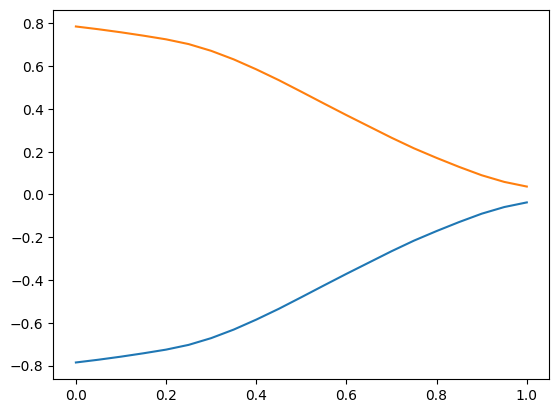

In [ ]:
# even_energies = np.array(even_energies)
# odd_energies = np.array(odd_energies)

plt.plot(H, even_energies)
plt.plot(H, odd_energies)


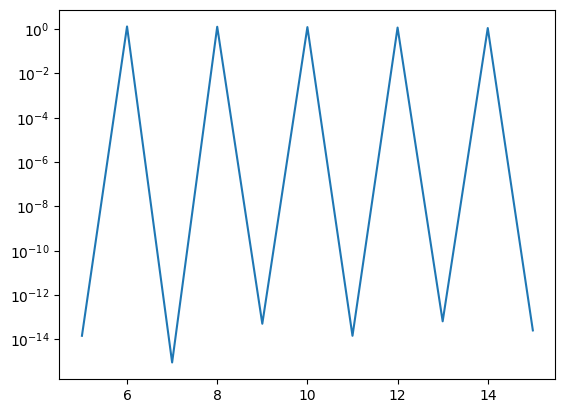

In [ ]:
plt.semilogy(L, np.abs(energy_differences).T)

In [ ]:
from quspin.operators import hamiltonian
from quspin.basis import spin_basis_1d
import numpy as np

def model_gap(L, J=1.0, h=0.5, k=0.1):
    basis = spin_basis_1d(int(L))

    static = [
        ["xx", [[J, i, i+1] for i in range(L-1)]],
        ["z",  [[h, i] for i in range(L)]],
        ['xx', [[k, i, i+2]for i in range(L-2)] ],
        ['zz', [[k, i, i+1]for i in range(L-2)] ],
        # ["xy", [[k, i, i+2] for i in range(L-2)]],
        # ["yx",[[-k, i, i+2] for i in range(L-2)]],
        # ["xyz", [[k, i, i+1, i+2] for i in range(L-2)]],
        # ["zyx", [[-k,  i, i+1, i+2] for i in range(L-2)]]
    ]

    H = hamiltonian(static, [], basis=basis, check_symm=False, check_herm=False)

    E, V= H.eigsh(k=4, which="SA")
    P_op = hamiltonian( [["z"*L, [[1.0] + list(range(L))]]], [], basis=basis, check_symm=False, check_herm=False)
    parities = np.array([np.vdot(V[:,i], P_op.dot(V[:,i])) for i in range(4)])

    even_check = (parities > 0)
    odd_check = (parities < 0)

    E_even = np.min(E[even_check])
    E_odd = np.min(E[odd_check])
    
    Delta_p = abs(E_even - E_odd)
    return Delta_p

In [ ]:
Ls = np.arange(4, 17)
gaps = np.array([model_gap(L) for L in Ls])


KeyboardInterrupt: 

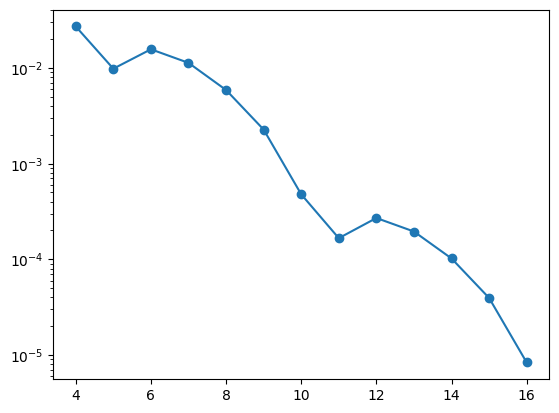

In [ ]:
import matplotlib.pyplot as plt
plt.semilogy(Ls, gaps, 'o-')
plt.show()

In [ ]:
from scipy.optimize import curve_fit
from scipy.signal import find_peaks
from tqdm import tqdm

def find_xi(lengths, energies, plotting=False):

    def line(x, xi, A):
        return A + np.exp(-x/xi)

    peaks, _ = find_peaks(energies)
    if len(peaks) < 2:
        return 0
    popt, _ = curve_fit(line, lengths[peaks], energies[peaks])

    if plotting:
        plt.semilogy(lengths, energies)
        plt.semilogy(lengths, line(lengths, *popt), label=f"{popt}")
        plt.legend()
        plt.show()

    return popt[0]

def find_q(lengths, energies, xi, plotting=False):
    def sinewave(x, q, phi):
        return np.abs(np.sin(q*x+phi))
    
    energies_rescaled = energies * np.exp(lengths/xi) 
    energies_rescaled = (energies_rescaled - np.min(energies_rescaled)) / (np.max(energies_rescaled) - np.min(energies_rescaled))

    peaks, _ = find_peaks(energies_rescaled)
    if len(peaks) < 2:
        return 0

    wavevector_guess = 2*np.abs(lengths[peaks[0]] - lengths[peaks[1]])
    popt, _ = curve_fit(sinewave, lengths, energies_rescaled, p0=[2*np.pi / wavevector_guess, lengths[peaks[0]]])

    if plotting:
        plt.plot(lengths, energies_rescaled, label="oscillations")
        plt.scatter(lengths[peaks], energies_rescaled[peaks])
        plt.plot(lengths, sinewave(lengths, *popt), label=f"q={popt[0]}")
        plt.legend()
        plt.show()

    return popt[0]

H = np.arange(0.1, 1, 0.1)
K = 0.1
Ls = np.arange(4, 18)

correlation_lengths = []
wavevectors = []
for h in tqdm(H):
    gaps = np.array([model_gap(L, h=h, k=K) for L in Ls])

    xi = find_xi(Ls, gaps)
    q = find_q(Ls, gaps, xi)

    correlation_lengths.append(xi)
    wavevectors.append(q)

  0%|          | 0/9 [00:00<?, ?it/s]/tmp/ipykernel_11025/4055769475.py:13: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(line, lengths[peaks], energies[peaks])
 22%|██▏       | 2/9 [04:51<16:58, 145.54s/it]/tmp/ipykernel_11025/4055769475.py:27: RuntimeWarning: divide by zero encountered in divide
  energies_rescaled = energies * np.exp(lengths/xi)
/tmp/ipykernel_11025/4055769475.py:28: RuntimeWarning: invalid value encountered in subtract
  energies_rescaled = (energies_rescaled - np.min(energies_rescaled)) / (np.max(energies_rescaled) - np.min(energies_rescaled))
/tmp/ipykernel_11025/4055769475.py:28: RuntimeWarning: invalid value encountered in scalar subtract
  energies_rescaled = (energies_rescaled - np.min(energies_rescaled)) / (np.max(energies_rescaled) - np.min(energies_rescaled))
100%|██████████| 9/9 [15:29<00:00, 103.32s/it]


[np.float64(7.2138886810677745), np.float64(0.8996140562316616), np.float64(0.9542197685526143), 0, 0, np.float64(1.100177829086468), 0, 0, 0, 0]
[np.float64(0.7054428923867164), np.float64(1.4844128508354646), np.float64(1.03310574557773), 0, 0, np.float64(0.6467881213418823), 0, 0, 0, 0]


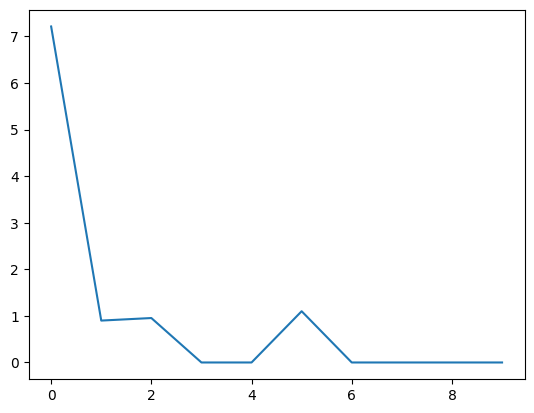

In [ ]:
print(correlation_lengths)
print(wavevectors)

plt.plot(correlation_lengths)
# plt.plot(wavevectors)

In [ ]:
from quspin.operators import hamiltonian
from quspin.basis import spin_basis_1d
import numpy as np

def model_gap(L, J=1.0, h=1.5, k=0.2):
    basis = spin_basis_1d(int(L))

    static = [
        ["xx", [[J, i, i+1] for i in range(L-1)]],
        ["z",  [[-h, i] for i in range(L)]],
        ["zz", [[k, i, i+1] for i in range(L-1)]],
        ["xx", [[k, i, i+2] for i in range(L-2)]]
        # ["xy", [[k, i, i+2] for i in range(L-2)]],
        # ["yx",[[-k, i, i+2] for i in range(L-2)]],
        # ["xyz", [[k, i, i+1, i+2] for i in range(L-2)]],
        # ["zyx", [[-k,  i, i+1, i+2] for i in range(L-2)]]
    ]

    H = hamiltonian(static, [], basis=basis)

    E, V= H.eigsh(k=4, which="SA")
    P_op = hamiltonian( [["z"*L, [[1.0] + list(range(L))]]], [], basis=basis )
    parities = np.array([np.vdot(V[:,i], P_op.dot(V[:,i])) for i in range(4)])

    even_check = (parities > 0)
    odd_check = (parities < 0)

    E_even = np.min(E[even_check])
    E_odd = np.min(E[odd_check])
    
    Delta_p = abs(E_even - E_odd)
    average = 0.5 * (E_even + E_odd)
    even_diff = E_even - average
    odd_diff = E_odd - average
    return np.array([even_diff, odd_diff])

L=14
h = np.arange(0, 6, 0.1)
gaps = [model_gap(L, k=hx) for hx in h]

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!


In [ ]:
from scipy.optimize import root_scalar
even_diff, odd_diff = np.array(gaps).T

plt.plot(h, even_diff, ls="--",label="even parity")
plt.plot(h, odd_diff, ls="--",label="odd parity")
# plt.xlim(0, 0.8)
lim = 1e-4
# plt.ylim(lim, -lim)
zero_crossings = []
for i in range(len(even_diff)-1):
    if even_diff[i] * even_diff[i+1] < 0:
        zero_crossings.append(i)

plt.scatter(h[zero_crossings], [0]*len(zero_crossings), marker='x', c='red')

plt.grid()
plt.legend()
plt.ylabel(r"E - $\tilde{E}$")
plt.xlabel(r"$h$")
plt.title(r"$\Delta_p$ for k=0.1")

ValueError: too many values to unpack (expected 2)

## Duality

In principle, we should be able to find

0it [00:00, ?it/s]

params: dual = False: 1, 0.0: L=8
Hermiticity check passed!
Symmetry checks passed!


/home/ioannisangelotassioulas/Documents/master_thesis/.venv/lib64/python3.10/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/ioannisangelotassioulas/Documents/master_thesis/.venv/lib64/python3.10/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


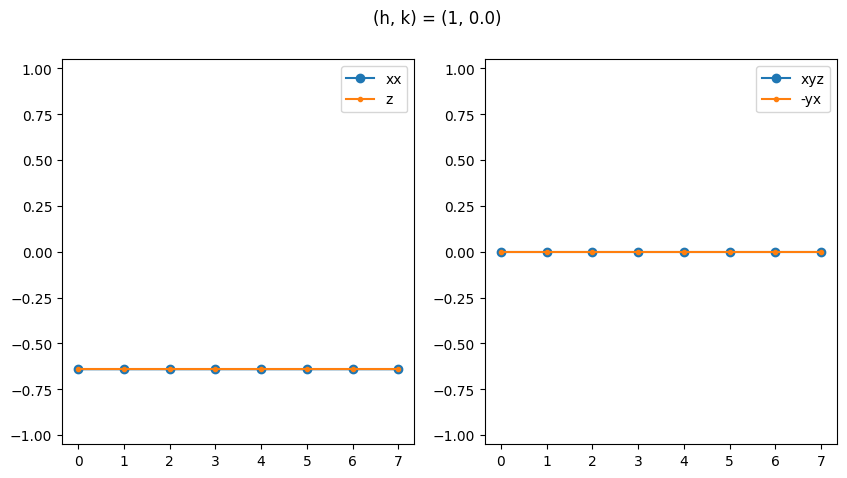

1it [00:00,  1.58it/s]

params: dual = False: 1, 0.01: L=8
Hermiticity check passed!
Symmetry checks passed!


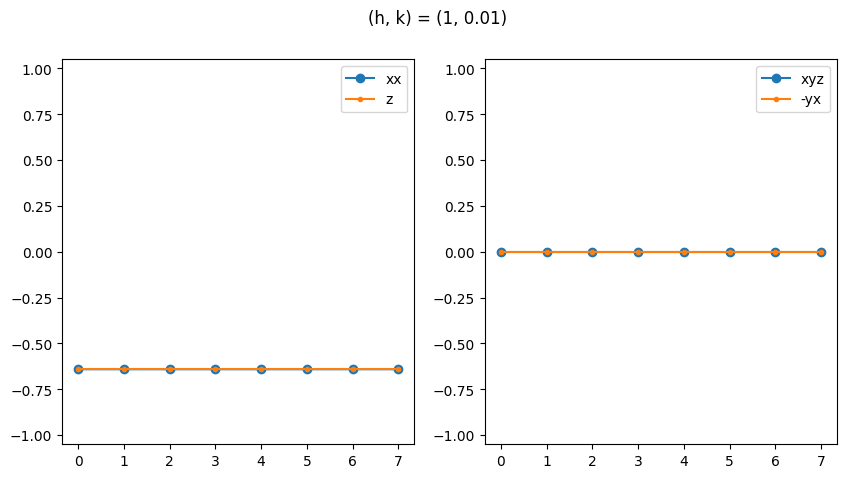

2it [00:01,  1.30it/s]

params: dual = False: 1, 0.02: L=8
Hermiticity check passed!
Symmetry checks passed!


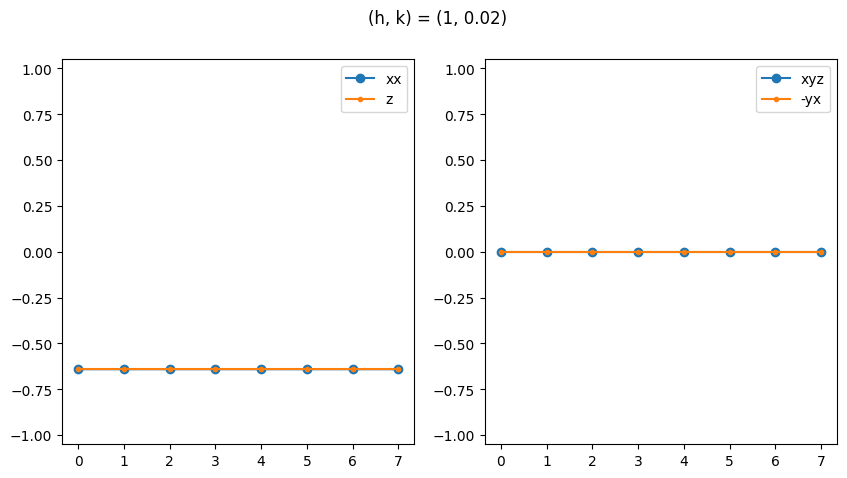

3it [00:02,  1.51it/s]

params: dual = False: 1, 0.03: L=8
Hermiticity check passed!
Symmetry checks passed!


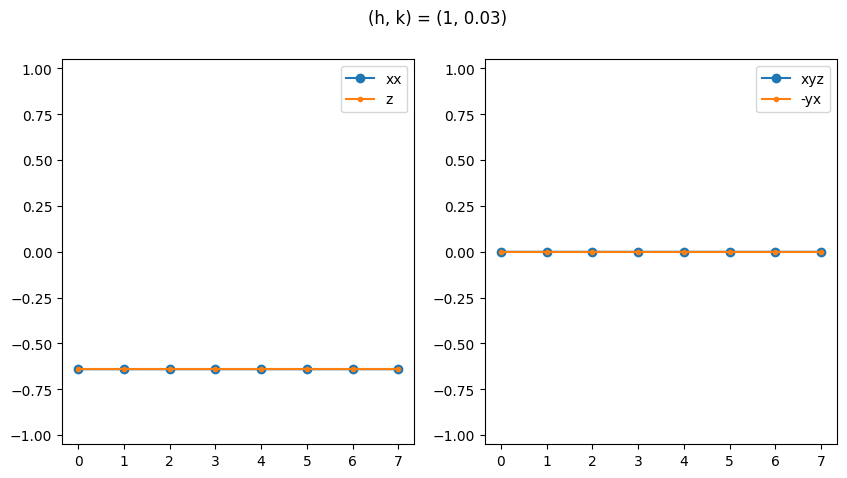

4it [00:02,  1.73it/s]

params: dual = False: 1, 0.04: L=8
Hermiticity check passed!
Symmetry checks passed!


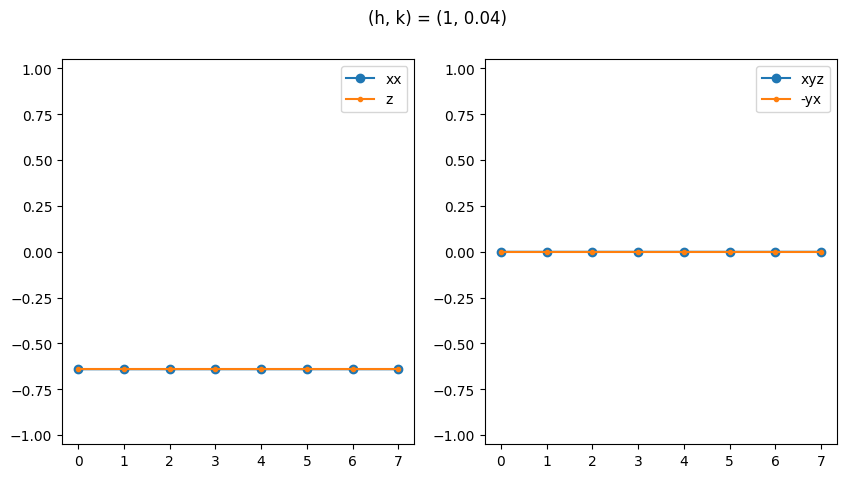

5it [00:02,  1.81it/s]

params: dual = False: 1, 0.05: L=8
Hermiticity check passed!
Symmetry checks passed!


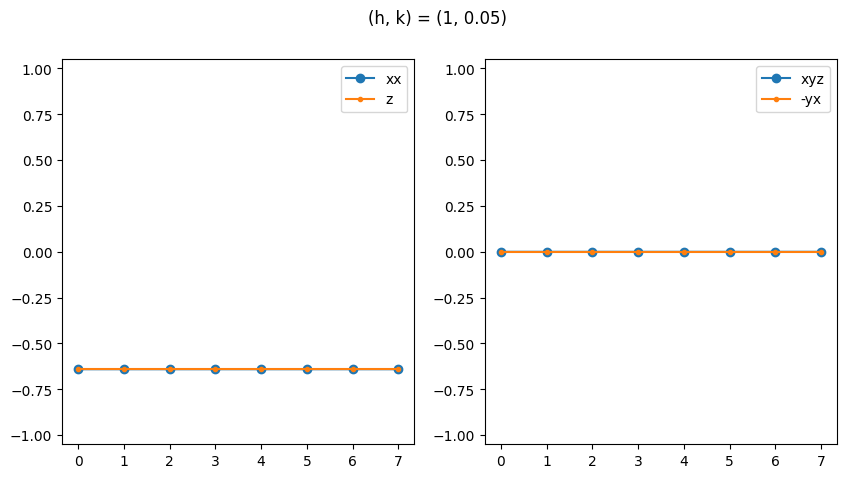

6it [00:03,  2.15it/s]

params: dual = False: 1, 0.06: L=8
Hermiticity check passed!
Symmetry checks passed!


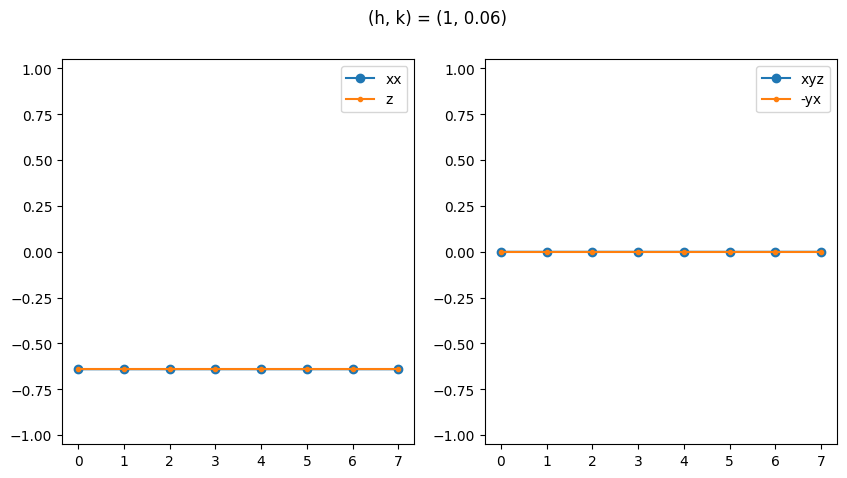

7it [00:03,  2.58it/s]

params: dual = False: 1, 0.07: L=8
Hermiticity check passed!
Symmetry checks passed!


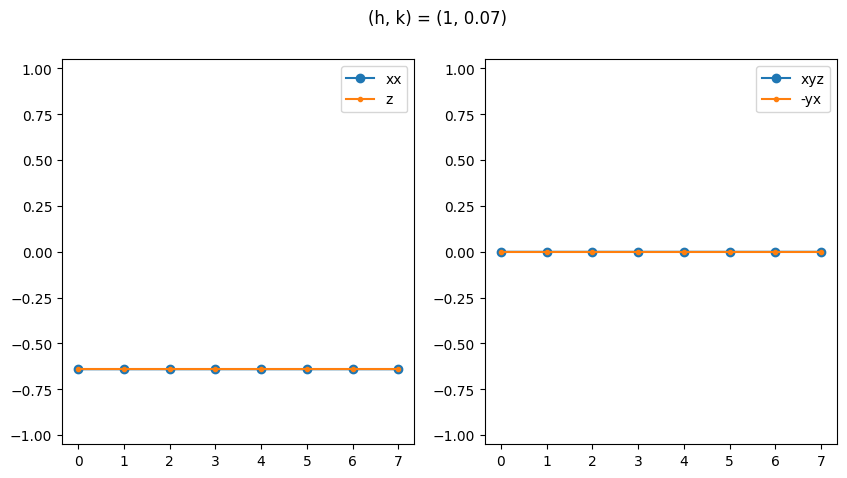

8it [00:03,  2.98it/s]

params: dual = False: 1, 0.08: L=8
Hermiticity check passed!
Symmetry checks passed!


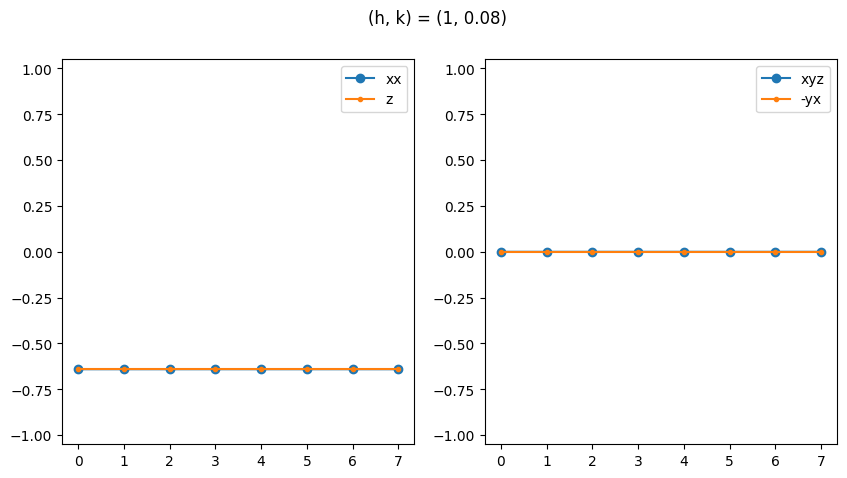

9it [00:04,  2.97it/s]

params: dual = False: 1, 0.09: L=8
Hermiticity check passed!
Symmetry checks passed!


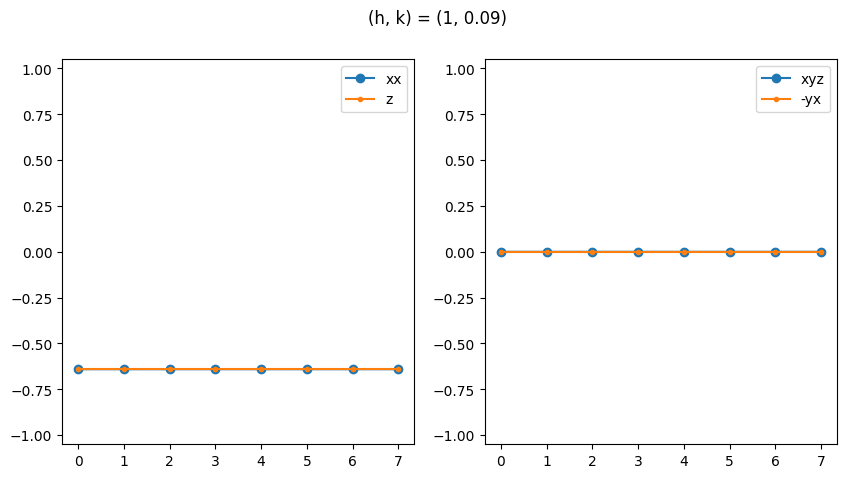

10it [00:04,  3.35it/s]

params: dual = False: 1, 0.1: L=8
Hermiticity check passed!
Symmetry checks passed!


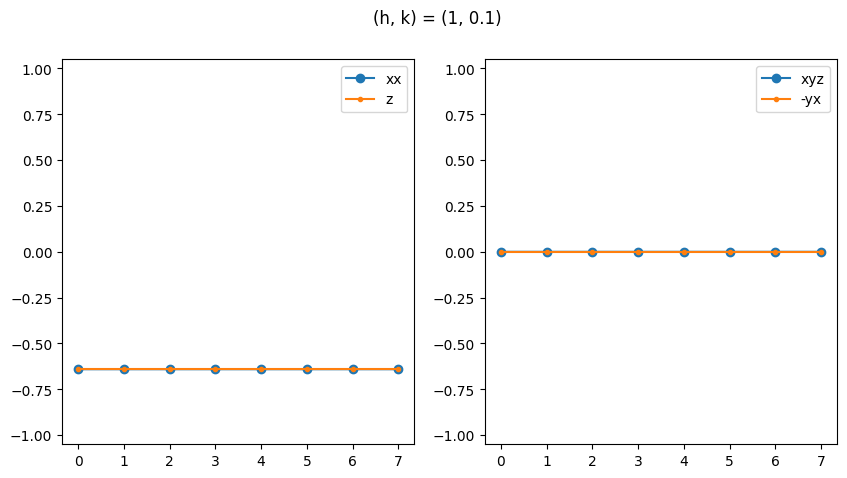

11it [00:04,  2.38it/s]


params: dual = False: 1, 0.11: L=8
Hermiticity check passed!
Symmetry checks passed!


KeyboardInterrupt: 

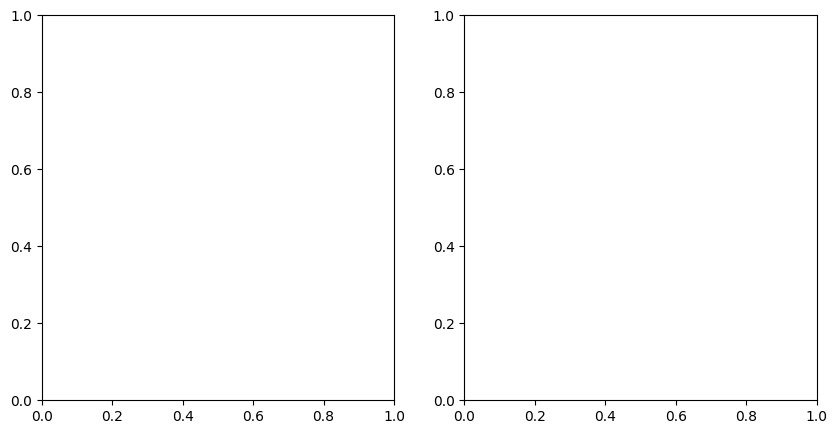

In [18]:
from quspin.basis import spin_basis_1d
from quspin.operators import hamiltonian, quantum_LinearOperator
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import gc
import os
import shutil

def exact_diagonalization_lengths(L, params, dual=False):
    """
    If dual=False:
        Returns true ground state.
    If dual=True:
        Returns the eigenstate whose energy matches
        E0_primal = h * E_dual.
    """

    L = int(L)
    J, h, k = params

    if dual:
        k = params[2] / params[1]
        h = 1 / params[1]

    h = np.round(h, 3)
    k = np.round(k, 3)
    print(f"params: dual = {dual}: {h}, {k}: L={L}")
    basis = spin_basis_1d(L=L, pauli=1)

    J_term  = [[J, i, (i+1)%L] for i in range(L)]
    h_term  = [[h, i] for i in range(L)]

    xy_term = [[k, i, (i+2)%L] for i in range(L)]
    yx_term = [[-k, i, (i+2)%L] for i in range(L)]
    xyz_term= [[k, i, (i+1)%L, (i+2)%L] for i in range(L)]
    zyx_term= [[-k, i, (i+1)%L, (i+2)%L] for i in range(L)]

    xx_term = [[k, i, (i+2)%L] for i in range(L)]
    zz_term = [[k, i, (i+1)%L] for i in range(L)]

    static = [
        ["xx", J_term],
        ["z", h_term],
        ["xy", xy_term],
        ["yx", yx_term],
        ["xyz", xyz_term],
        ["zyx", zyx_term],
        # ['xx', xx_term],
        # ['zz', zz_term]
    ]

    epsilon = 1e-4
    if dual:
        static.append(["z", [[epsilon, 0]]])
    else:
        static.append(["xx", [[epsilon, 0, 1]]]) 

    H = hamiltonian(static, [], basis=basis,
                    dtype=np.complex128)

    if basis.Ns <= 2048:
        E, V = H.eigh()
    else:
        E, V = H.eigsh(k=min(40, basis.Ns-2), which="SA")
    idx = np.argsort(np.real(E))
    E = np.real(E[idx]); V = V[:, idx]
    
    return E, V, basis

def magnetization_string(op, psi, basis, dist=1):
    """
    Measure <op_i op_{i+dist} ...> on even (regular) or odd (dual) sites.
    The basis is inferred from the size of psi.
    """

    # infer active lattice size
    L_active = int(np.log2(psi.size))

    # determine site mapping
    start = 0
    step = 1

    active_sites = range(L_active)

    n_ops = len(op)
    values = []

    for i in active_sites:
        # reindex sites to 0..L_active-1
        indices = [(i + j*dist) % L_active for j in range(n_ops)]
        static = [[op, [[1.0, *indices]]]]
        operator = hamiltonian(
            static, [],
            basis=basis,
            check_symm=False,
            check_herm=False,
            dtype=np.complex128,
        )

        val = operator.expt_value(psi)
        values.append(val)

    return np.array(values)

J = 1
l = 8
h = 1
K = np.arange(0, 0.2, 0.01)

energies = []
energies_dual = []

XX_mean = []
Z_mean = []
YIX_mean = []
XYZ_mean = []
sigmax = []
sigmay = []
sigmaz = []

for i, k in tqdm(enumerate(K)):
    params = (J, h, k)

    # Check for ground states to evaluate
    energ, psi, basis = exact_diagonalization_lengths(l, params)
    # energ_dual, psi_dual, basis_dual = exact_diagonalization_lengths(l, params, dual=True)

    # diff = []
    # for i, prim_en in enumerate(energ[:2]):
    #     for j, dual_en in enumerate(energ_dual[:2]):
    #         diff.append((i, j, np.abs(prim_en - h*dual_en)))
            
    # val = np.argmin(np.array(diff).T[2])
    # i, j, difference = diff[val]
    # energies.append(energ[i])
    # energies_dual.append(h*energ_dual[j])

    # plt.plot(energ[:10], label=f"energy, state number {i+1}")
    # plt.plot(h*energ_dual[:10], label=f"dual energy rescaled, state number {j+1}")
    # plt.scatter(i, energ[i])
    # plt.scatter(j, h*energ_dual[j], marker="x")
    # plt.axhline(energ[i], c='red', ls='--')
    # plt.xlabel("State number")
    # plt.ylabel("energy")
    # plt.title(f"energy spectrum, L={l}")
    # plt.legend()
    # plt.show()

    psi0 = psi[:, 0]
    # psi0_dual = psi_dual[:, 0]

    # take measurements
    fig, ax = plt.subplots(1, 2, figsize=(10,5))

    # # XX and Z
    XX = magnetization_string('xx', psi0, basis)
    Z = magnetization_string('z', psi0_dual, basis_dual)


    ax[0].plot(XX, marker='o', label=f"xx")
    ax[0].plot(Z, marker='.', label=f"z")
    XX_mean.append(np.mean(XX))
    Z_mean.append(np.mean(Z))
    # print(XX_mean[-1])
    # print(Z_mean[-1])

    # ### XYZ and YX
    XX = magnetization_string('xyz', psi0, basis)
    Z = magnetization_string('yx', psi0_dual, basis_dual, dist=2)
    YIX_mean.append(-np.mean(Z))
    XYZ_mean.append(np.mean(XX))
    # print(YIX_mean[-1])
    # print(XYZ_mean[-1])


    scaling =  (np.max(Z) - np.min(Z))/(np.max(XX) - np.min(XX))
    ax[1].plot((XX), marker='o', label=f"xyz")
    ax[1].plot(-(Z), marker='.', label=f"-yx")


    fig.suptitle(f"(h, k) = ({h}, {k})")
    ax[0].set_ylim(-1.05, 1.05)
    ax[1].set_ylim(-1.05, 1.05)

    ax[0].legend()
    ax[1].legend()

    plt.show()


In [ ]:
def exact_diagonalization_lengths(L, params, dual=False):
    J, h, k = params

    homey = f"ed_lengths/{J}-{h}-{k}-dual" if dual else f"ed_lengths/{J}-{h}-{k}"
    homey = os.path.join(os.getcwd(), homey)
    if not os.path.exists(homey):
        os.mkdir(homey)

    folder_eigenstates = os.path.join(homey, f"L{L}_state.npy")
    folder_eigenvalues = os.path.join(homey, "energies")
    basis = spin_basis_1d(int(L))

    if dual:
        k = k/h
        h = 1/h

    # Hamiltonian terms
    J_term = [[J, i, (i+1)%L] for i in range(L)]
    h_term = [[h, i] for i in range(L)]
    xy_term = [[k, i, (i+2)%L] for i in range(L)]
    yx_term = [[-k, i, (i+2)%L] for i in range(L)]
    xyz_term = [[k, i, (i+1)%L, (i+2)%L] for i in range(L)]
    zyx_term = [[-k, i, (i+1)%L, (i+2)%L] for i in range(L)]

    static = [
        ["xx", J_term],
        ["z", h_term],
        ["xy", xy_term],
        ["yx", yx_term],
        ["xyz", xyz_term], 
        ["zyx", zyx_term]
    ]

    H = hamiltonian(static, [], basis=basis,
                    dtype=np.complex128,
                    check_symm=True,
                    check_herm=True)

    # Global parity operator P = ∏ X_i
    P_op = quantum_LinearOperator(
        [["x"*L, [[1.0, *range(L)]]]],
        basis=basis,
        dtype=np.complex128,
    )

    # Diagonalize sufficiently many states
    E, V = H.eigsh(k=20, which="SA")

    # Compute parity eigenvalues
    parities = np.array([
        np.vdot(V[:, i], P_op.dot(V[:, i]))
        for i in range(V.shape[1])
    ])

    parities = np.real_if_close(parities)
    parities = np.sign(parities)

    even_indices = np.where(parities > 0)[0]
    odd_indices  = np.where(parities < 0)[0]

    if len(even_indices) == 0 or len(odd_indices) == 0:
        raise RuntimeError("Not enough states computed to resolve both parity sectors.")

    # Lowest energy in each sector
    i_even_min = even_indices[np.argmin(E[even_indices])]
    i_odd_min  = odd_indices[np.argmin(E[odd_indices])]

    E_even_min = E[i_even_min]
    E_odd_min  = E[i_odd_min]

    psi_even = V[:, i_even_min]
    psi_odd  = V[:, i_odd_min]

    # Save correct sector depending on duality
    if dual:
        E_save = E_odd_min
        psi_save = psi_odd
    else:
        E_save = E_even_min
        psi_save = psi_even

    with open(folder_eigenvalues, 'a') as file:
        file.write(f"{E_save}\n")

    np.save(folder_eigenstates, psi_save)

energies = []
def magnetization_string(op, psi, dist=1):
    """
    Measure <op_i op_{i+dist} ...> on even (regular) or odd (dual) sites.
    The basis is inferred from the size of psi.
    """

    # infer active lattice size
    L_active = int(np.log2(psi.size))
    basis = spin_basis_1d(L_active)

    # determine site mapping
    start = 0
    step = 1

    active_sites = list(range(start, L_active, step))
    idx_map = {site: i for i, site in enumerate(active_sites)}

    n_ops = len(op)
    values = []

    for i in active_sites:
        # reindex sites to 0..L_active-1
        indices = [idx_map[(i + j*dist) % L_active] for j in range(n_ops)]

        static = [
            [op, [[1.0, *indices]]]
        ]
        operator = quantum_LinearOperator(
            static,
            basis=basis,
            check_symm=False,
            check_herm=False,
            dtype=np.complex128,
        )

        val = operator.expt_value(psi)
        values.append(np.real(val))

    return np.array(values)

J = 1
h = 0.1
k = 1
L = np.arange(5,10, 1)

folder_eigenvalues = f"ed_lengths/{J}-{h}-{k}-dual/energies"
if os.path.exists(folder_eigenvalues):
    os.remove(folder_eigenvalues)
folder_eigenvalues = f"ed_lengths/{J}-{h}-{k}/energies"
if os.path.exists(folder_eigenvalues):
    os.remove(folder_eigenvalues)

       
for l in tqdm(L):
    print(l)
    params = (J, h, k)
    print("regular:")
    exact_diagonalization_lengths(l, params)
    print("dual:")
    exact_diagonalization_lengths(l, params, dual=True)



  0%|          | 0/5 [00:00<?, ?it/s]

 40%|████      | 2/5 [00:00<00:00, 11.29it/s]

5
regular:
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
dual:
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
6
regular:
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
dual:
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
7
regular:
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
dual:
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
8
regular:
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
dual:
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!


 80%|████████  | 4/5 [00:01<00:00,  2.00it/s]

9
regular:
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
dual:
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!


100%|██████████| 5/5 [00:03<00:00,  1.59it/s]


In [21]:
J = 1
l = 8
h = 0.5
K = np.arange(0, 0.3, 0.01)  # small jumps to detect E

energies = []
XX_mean, Z_mean, YIX_mean, XYZ_mean = [], [], [], []
sigmax, sigmay, sigmaz = [], [], []

for i, k in tqdm(enumerate(K), total=len(K)):
    params = (J, h, k)

    energ, psi, basis = exact_diagonalization_lengths(l, params)
    energy_0 = energ[0]
    psi0 = psi[:, 0]

    energies.append(energy_0)


# # arrays
# K = np.asarray(K, dtype=float)
# energies = np.asarray(energies, dtype=float)

# # 1st and 2nd derivatives of ground-state energy
# dE_dK = np.gradient(energies, K)
# dyn_coeff = np.gradient(dE_dK, K)   # dynamical coefficient = E''(K)

# # often used: location of strongest response
# k_star = K[np.argmax(np.abs(dyn_coeff))]
# print("K* =", k_star)


 10%|█         | 3/30 [00:00<00:00, 29.26it/s]

params: dual = False: 0.5, 0.0: L=8
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.5, 0.01: L=8
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.5, 0.02: L=8
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.5, 0.03: L=8
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.5, 0.04: L=8
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.5, 0.05: L=8
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.5, 0.06: L=8
Hermiticity check passed!
Symmetry checks passed!


 37%|███▋      | 11/30 [00:00<00:00, 31.44it/s]

params: dual = False: 0.5, 0.07: L=8
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.5, 0.08: L=8
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.5, 0.09: L=8
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.5, 0.1: L=8
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.5, 0.11: L=8
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.5, 0.12: L=8
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.5, 0.13: L=8
Hermiticity check passed!
Symmetry checks passed!


 63%|██████▎   | 19/30 [00:00<00:00, 31.49it/s]

params: dual = False: 0.5, 0.14: L=8
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.5, 0.15: L=8
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.5, 0.16: L=8
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.5, 0.17: L=8
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.5, 0.18: L=8
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.5, 0.19: L=8
Hermiticity check passed!
Symmetry checks passed!


 77%|███████▋  | 23/30 [00:00<00:00, 26.85it/s]

params: dual = False: 0.5, 0.2: L=8
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.5, 0.21: L=8
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.5, 0.22: L=8
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.5, 0.23: L=8
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.5, 0.24: L=8
Hermiticity check passed!
Symmetry checks passed!


100%|██████████| 30/30 [00:01<00:00, 28.98it/s]

params: dual = False: 0.5, 0.25: L=8
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.5, 0.26: L=8
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.5, 0.27: L=8
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.5, 0.28: L=8
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.5, 0.29: L=8
Hermiticity check passed!
Symmetry checks passed!


In [20]:
from scipy.optimize import curve_fit
import numpy as np
from tqdm import tqdm

# --- Helpers for PT/Lifshitz diagnostics ---
def sz_table_from_basis_states(states, L):
    bits = ((states[:, None] >> np.arange(L)) & 1).astype(np.int8)
    return bits - 0.5  # {-1/2, +1/2}

def Szz_of_q(psi0, basis, L):
    p = np.abs(psi0) ** 2
    sz = sz_table_from_basis_states(basis.states, L)  # (Ns, L)

    m = np.sum(p[:, None] * sz, axis=0)
    mbar = np.mean(m)

    C = np.zeros(L, dtype=float)
    for r in range(L):
        C[r] = np.mean(np.sum(p[:, None] * (sz * np.roll(sz, -r, axis=1)), axis=0)) - mbar**2

    q = 2 * np.pi * np.arange(L) / L
    S = np.real(np.fft.fft(C))
    return q, S

def power_law(x, A, Kc, beta):
    z = np.clip(x - Kc, 0.0, None)
    return A * (z ** beta)

J = 1
l = 8
h = 0.5
K = np.arange(0, 0.3, 0.01)  # small jumps to detect E

energies = []
gap = []
qstar = []

XX_mean = []
Z_mean = []
YIX_mean = []
XYZ_mean = []
sigmax = []
sigmay = []
sigmaz = []

for i, k in tqdm(enumerate(K), total=len(K)):
    params = (J, h, k)

    energ, psi, basis = exact_diagonalization_lengths(l, params)
    energy_0 = energ[0]
    psi0 = psi[:, 0]

    energies.append(energy_0)
    gap.append(energ[1] - energ[0])

    q, S = Szz_of_q(psi0, basis, l)
    i_max = np.argmax(S[1:]) + 1  # ignore q=0
    qstar.append(q[i_max])

# Arrays
K = np.asarray(K, dtype=float)
energies = np.asarray(energies, dtype=float)
gap = np.asarray(gap, dtype=float)
qstar = np.asarray(qstar, dtype=float)

# Dynamical coefficient proxy from ground-state energy curvature
d2E_dK2 = np.gradient(np.gradient(energies, K), K)

# Incommensurability wrt q0=pi
q0 = np.pi
delta_q = np.abs(qstar - q0)

# Fit delta_q ~ A (K-Kc)^beta (PT expects beta ~ 1/2)
fit = None
nonzero = np.where(delta_q > 1e-8)[0]
if len(nonzero) >= 4:
    i0 = nonzero[0]
    K_fit = K[i0:]
    dq_fit = delta_q[i0:]
    p0 = (1.0, K[i0], 0.5)
    bounds = ([0.0, K.min(), 0.0], [np.inf, K.max(), 2.0])
    try:
        popt, pcov = curve_fit(power_law, K_fit, dq_fit, p0=p0, bounds=bounds, maxfev=20000)
        fit = {
            "A": float(popt[0]),
            "Kc": float(popt[1]),
            "beta": float(popt[2]),
            "beta_err": float(np.sqrt(np.diag(pcov))[2]) if pcov.size else np.nan,
        }
    except Exception as e:
        fit = {"error": str(e)}

print("min gap:", float(gap.min()), "at K =", float(K[np.argmin(gap)]))
print("max |d2E/dK2|:", float(np.max(np.abs(d2E_dK2))), "at K =", float(K[np.argmax(np.abs(d2E_dK2))]))

if fit is not None and "error" not in fit:
    print("Fit delta_q = A*(K-Kc)^beta ->", fit)
    if abs(fit["beta"] - 0.5) < 0.2:
        print("beta ~ 1/2: consistent with Pokrovsky-Talapov-like onset.")
    else:
        print("beta not close to 1/2: could indicate Lifshitz-like behavior (or finite-size effects).")
elif fit is not None:
    print("Fit failed:", fit["error"])
else:
    print("Not enough incommensurate points to fit beta.")


 13%|█▎        | 4/30 [00:00<00:00, 35.09it/s]

params: dual = False: 0.5, 0.0: L=8
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.5, 0.01: L=8
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.5, 0.02: L=8
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.5, 0.03: L=8
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.5, 0.04: L=8
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.5, 0.05: L=8
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.5, 0.06: L=8
Hermiticity check passed!
Symmetry checks passed!


 27%|██▋       | 8/30 [00:00<00:00, 31.91it/s]

params: dual = False: 0.5, 0.07: L=8
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.5, 0.08: L=8
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.5, 0.09: L=8
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.5, 0.1: L=8
Hermiticity check passed!
Symmetry checks passed!


 50%|█████     | 15/30 [00:00<00:00, 24.08it/s]

params: dual = False: 0.5, 0.11: L=8
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.5, 0.12: L=8
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.5, 0.13: L=8
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.5, 0.14: L=8
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.5, 0.15: L=8
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.5, 0.16: L=8
Hermiticity check passed!
Symmetry checks passed!


 73%|███████▎  | 22/30 [00:00<00:00, 27.48it/s]

params: dual = False: 0.5, 0.17: L=8
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.5, 0.18: L=8
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.5, 0.19: L=8
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.5, 0.2: L=8
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.5, 0.21: L=8
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.5, 0.22: L=8
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.5, 0.23: L=8
Hermiticity check passed!
Symmetry checks passed!


100%|██████████| 30/30 [00:01<00:00, 28.76it/s]

params: dual = False: 0.5, 0.24: L=8
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.5, 0.25: L=8
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.5, 0.26: L=8
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.5, 0.27: L=8
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.5, 0.28: L=8
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.5, 0.29: L=8
Hermiticity check passed!
Symmetry checks passed!
min gap: 0.001388206994088037 at K = 0.25
max |d2E/dK2|: 527.520260269858 at K = 0.26
Fit delta_q = A*(K-Kc)^beta -> {'A': 2.247863709034079, 'Kc': 3.6857822816936465e-23, 'beta': 6.368616853455309e-16, 'beta_err': 0.052900527735218604}
beta not close to 1/2: could indicate Lifshitz-like behavior (or finite-size effects).


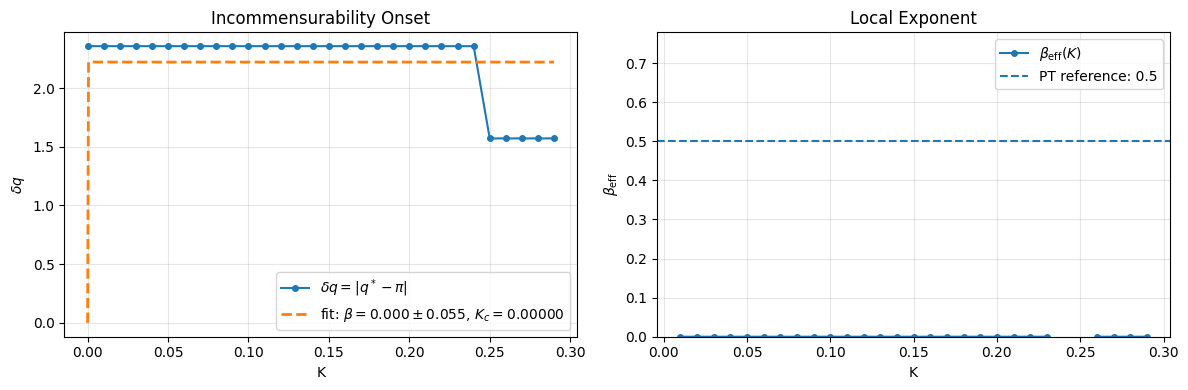

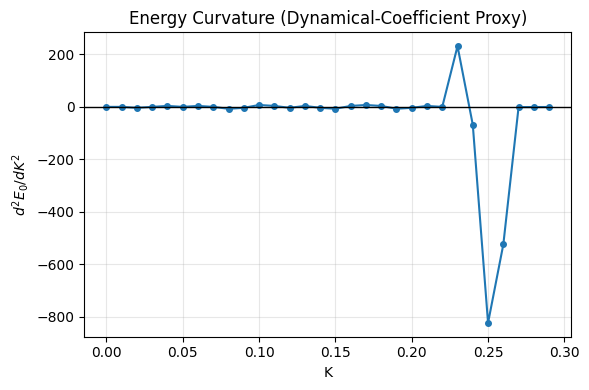

In [16]:
import matplotlib.pyplot as plt

# ---------- Plot 1: incommensurability + fitted PT exponent beta ----------
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Left: delta_q(K) with fit
ax[0].plot(K, delta_q, "o-", ms=4, lw=1.5, label=r"$\delta q = |q^*-\pi|$")
if fit is not None and "error" not in fit:
    K_dense = np.linspace(K.min(), K.max(), 500)
    dq_dense = power_law(K_dense, fit["A"], fit["Kc"], fit["beta"])
    ax[0].plot(K_dense, dq_dense, "--", lw=2,
               label=rf"fit: $\beta={fit['beta']:.3f}\pm{fit['beta_err']:.3f}$, $K_c={fit['Kc']:.5f}$")
ax[0].set_xlabel("K")
ax[0].set_ylabel(r"$\delta q$")
ax[0].set_title("Incommensurability Onset")
ax[0].legend()
ax[0].grid(alpha=0.3)

# Right: effective local exponent beta_eff(K) = d ln(delta_q)/d ln(K-Kc)
if fit is not None and "error" not in fit:
    Kc_est = fit["Kc"]
    mask = (K > Kc_est + 1e-6) & (delta_q > 1e-10)
    if np.sum(mask) >= 3:
        x = np.log(K[mask] - Kc_est)
        y = np.log(delta_q[mask])
        beta_eff = np.gradient(y, x)
        ax[1].plot(K[mask], beta_eff, "o-", ms=4, lw=1.5, label=r"$\beta_{\mathrm{eff}}(K)$")
        ax[1].axhline(0.5, ls="--", lw=1.5, label="PT reference: 0.5")
        ax[1].set_ylim(bottom=0)
        ax[1].legend()
    else:
        ax[1].text(0.1, 0.5, "Not enough points above $K_c$ for local exponent",
                   transform=ax[1].transAxes)
ax[1].set_xlabel("K")
ax[1].set_ylabel(r"$\beta_{\mathrm{eff}}$")
ax[1].set_title("Local Exponent")
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ---------- Plot 2: dynamical coefficient proxy ----------
plt.figure(figsize=(6, 4))
plt.plot(K, d2E_dK2, "o-", ms=4, lw=1.5)
plt.axhline(0, color="k", lw=1)
plt.xlabel("K")
plt.ylabel(r"$d^2E_0/dK^2$")
plt.title("Energy Curvature (Dynamical-Coefficient Proxy)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [23]:
J = 1
l = 8
h = 0.5
K = np.arange(0, 0.3, 0.01)

energies = []
gap = []

for i, k in tqdm(enumerate(K), total=len(K)):
    params = (J, h, k)
    energ, psi, basis = exact_diagonalization_lengths(l, params)

    E0 = energ[0]
    E1 = energ[1]

    energies.append(E0)
    gap.append(E1 - E0)

K = np.asarray(K, dtype=float)
energies = np.asarray(energies, dtype=float)
gap = np.asarray(gap, dtype=float)

dE_dK = np.gradient(energies, K)
dyn_coeff = np.gradient(dE_dK, K)

print("Minimum gap:", float(gap.min()), "at K =", float(K[np.argmin(gap)]))


  0%|          | 0/30 [00:00<?, ?it/s]

params: dual = False: 0.5, 0.0: L=8
Hermiticity check passed!
Symmetry checks passed!


  3%|▎         | 1/30 [00:00<00:21,  1.36it/s]

params: dual = False: 0.5, 0.01: L=8
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.5, 0.02: L=8
Hermiticity check passed!
Symmetry checks passed!


 13%|█▎        | 4/30 [00:01<00:05,  4.54it/s]

...

params: dual = False: 0.5, 0.14: L=8
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.5, 0.15: L=8
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.5, 0.16: L=8
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.5, 0.17: L=8
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.5, 0.18: L=8
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.5, 0.19: L=8
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.5, 0.2: L=8
Hermiticity check passed!
Symmetry checks passed!


 87%|████████▋ | 26/30 [00:03<00:00, 13.38it/s]

params: dual = False: 0.5, 0.21: L=8
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.5, 0.22: L=8
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.5, 0.23: L=8
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.5, 0.24: L=8
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.5, 0.25: L=8
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.5, 0.26: L=8
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.5, 0.27: L=8
Hermiticity check passed!
Symmetry checks passed!


100%|██████████| 30/30 [00:03<00:00,  8.18it/s]

params: dual = False: 0.5, 0.28: L=8
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.5, 0.29: L=8
Hermiticity check passed!
Symmetry checks passed!
Minimum gap: 0.001388206994088037 at K = 0.25


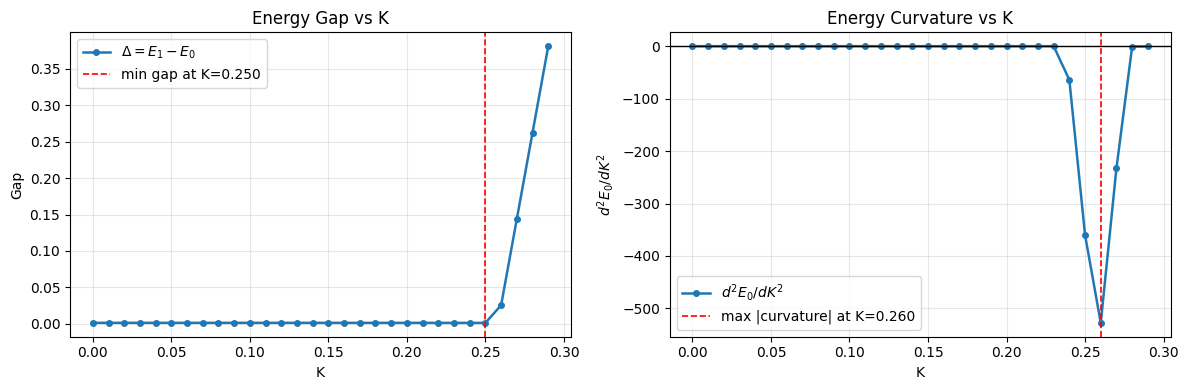

In [24]:
import matplotlib.pyplot as plt

k_gap = K[np.argmin(gap)]
k_dyn = K[np.argmax(np.abs(dyn_coeff))]

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Energy gap
ax[0].plot(K, gap, "o-", lw=1.8, ms=4, label=r"$\Delta = E_1 - E_0$")
ax[0].axvline(k_gap, color="r", ls="--", lw=1.2, label=fr"min gap at K={k_gap:.3f}")
ax[0].set_xlabel("K")
ax[0].set_ylabel("Gap")
ax[0].set_title("Energy Gap vs K")
ax[0].grid(alpha=0.3)
ax[0].legend()

# Dynamical coefficient proxy (curvature)
ax[1].plot(K, dyn_coeff, "o-", lw=1.8, ms=4, label=r"$d^2E_0/dK^2$")
ax[1].axvline(k_dyn, color="r", ls="--", lw=1.2, label=fr"max |curvature| at K={k_dyn:.3f}")
ax[1].axhline(0, color="k", lw=1)
ax[1].set_xlabel("K")
ax[1].set_ylabel(r"$d^2E_0/dK^2$")
ax[1].set_title("Energy Curvature vs K")
ax[1].grid(alpha=0.3)
ax[1].legend()

plt.tight_layout()
plt.show()


h=0.1:   0%|          | 0/4 [00:00<?, ?it/s]

params: dual = False: 0.1, 0.0: L=8
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.1, 0.01: L=8
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.1, 0.02: L=8
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.1, 0.03: L=8
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.1, 0.04: L=8
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.1, 0.05: L=8
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.1, 0.06: L=8
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.1, 0.07: L=8
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.1, 0.08: L=8
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.1, 0.09: L=8
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.1, 0.1: L=8
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.1, 0.11: L=8
Hermitic

h=0.1:  25%|██▌       | 1/4 [00:03<00:11,  3.67s/it]

params: dual = False: 0.1, 0.29: L=8
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.1, 0.3: L=8
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.1, 0.31: L=8
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.1, 0.32: L=8
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.1, 0.33: L=8
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.1, 0.34: L=8
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.1, 0.35: L=8
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.1, 0.0: L=10
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.1, 0.01: L=10
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.1, 0.02: L=10
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.1, 0.03: L=10
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.1, 0.04: L=10
Her

h=0.1:  50%|█████     | 2/4 [00:15<00:17,  8.73s/it]

...

params: dual = False: 0.3, 0.0: L=12
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.3, 0.01: L=12
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.3, 0.02: L=12
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.3, 0.03: L=12
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.3, 0.04: L=12
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.3, 0.05: L=12
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.3, 0.06: L=12
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.3, 0.07: L=12
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.3, 0.08: L=12
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.3, 0.09: L=12
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.3, 0.1: L=12
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.3, 0.11: L

h=0.3:  75%|███████▌  | 3/4 [00:32<00:12, 12.72s/it]

params: dual = False: 0.3, 0.0: L=14
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.3, 0.01: L=14
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.3, 0.02: L=14
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.3, 0.03: L=14
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.3, 0.04: L=14
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.3, 0.05: L=14
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.3, 0.06: L=14
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.3, 0.07: L=14
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.3, 0.08: L=14
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.3, 0.09: L=14
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.3, 0.1: L=14
Hermiticity check passed!
Symmetry checks passed!
params: dual = False: 0.3, 0.11: L

h=0.3: 100%|██████████| 4/4 [01:55<00:00, 28.87s/it]


[h=0.1] q*-anomaly candidate Kc ~ 0.2600
[h=0.1] max z(K) ~ 19.440 ± 4.929 at K=0.1300 (R^2=0.940)


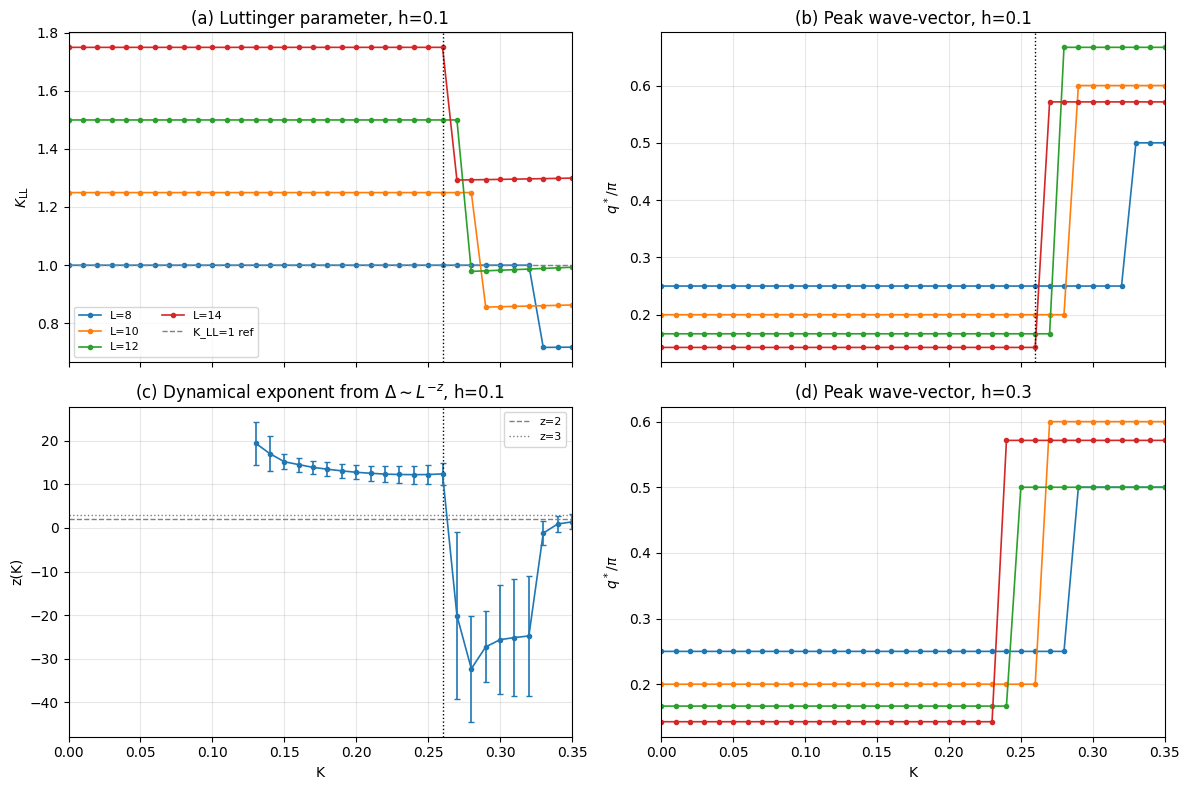

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# ------------------- settings -------------------
J = 1.0
h_main = 0.1   # "vertical cut" 1
h_alt  = 0.3   # "vertical cut" 2
K_grid = np.linspace(0.0, 0.35, 36)   # increase points for smoother curves
L_list = np.array([8, 10, 12, 14], dtype=int)  # increase if affordable

# ------------------- helpers -------------------
def low2_ground_state(L, J, h, k):
    out = exact_diagonalization_lengths(int(L), (float(J), float(h), float(k)))
    if out is None:
        raise RuntimeError("exact_diagonalization_lengths returned None. It must return (E, V, basis).")
    E, V, basis = out
    E = np.asarray(E)
    idx = np.argsort(np.real(E))
    E = np.real(E[idx])
    V = V[:, idx]
    return E[0], E[1], V[:, 0], basis

def sz_table_from_basis_states(states, L):
    bits = ((states[:, None] >> np.arange(L)) & 1).astype(np.int8)
    return bits - 0.5  # spin-1/2

def Szz_q_from_psi(psi0, basis, L):
    p = np.abs(psi0) ** 2
    sz = sz_table_from_basis_states(basis.states, L)  # (Ns, L)

    mz = p @ sz
    mbar = np.mean(mz)

    C = np.zeros(L, dtype=float)
    for r in range(L):
        C[r] = np.mean(p @ (sz * np.roll(sz, -r, axis=1))) - mbar**2

    q = 2 * np.pi * np.arange(L) / L
    S = np.real(np.fft.fft(C))
    return q, S

# ------------------- compute observables -------------------
h_cuts = [h_main, h_alt]
data = {}

for h in h_cuts:
    gap = np.full((len(L_list), len(K_grid)), np.nan, dtype=float)
    qstar = np.full_like(gap, np.nan)
    Kll = np.full_like(gap, np.nan)

    for iL, L in enumerate(tqdm(L_list, desc=f"h={h}")):
        for iK, k in enumerate(K_grid):
            E0, E1, psi0, basis = low2_ground_state(L, J, h, k)
            gap[iL, iK] = max(E1 - E0, 1e-14)

            q, S = Szz_q_from_psi(psi0, basis, L)

            # q* from positive branch, excluding q=0
            i_peak = np.argmax(S[1:L // 2 + 1]) + 1
            qstar[iL, iK] = q[i_peak]

            # K_LL ~ pi * S(q1) / q1 with q1=2pi/L
            q1 = q[1]
            Kll[iL, iK] = np.pi * S[1] / q1

    data[h] = {"gap": gap, "qstar": qstar, "Kll": Kll}

# ------------------- dynamical exponent z(K) from gap ~ L^{-z} -------------------
gap_main = data[h_main]["gap"]
z_vals = np.full(len(K_grid), np.nan, dtype=float)
z_errs = np.full(len(K_grid), np.nan, dtype=float)
r2_vals = np.full(len(K_grid), np.nan, dtype=float)

for iK in range(len(K_grid)):
    g = gap_main[:, iK]
    m = np.isfinite(g) & (g > 1e-12)
    if np.sum(m) < 3:
        continue

    x = np.log(L_list[m].astype(float))
    y = np.log(g[m])

    (slope, intercept), cov = np.polyfit(x, y, 1, cov=True)
    yhat = slope * x + intercept
    ss_res = np.sum((y - yhat) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)

    z_vals[iK] = -slope
    z_errs[iK] = np.sqrt(max(cov[0, 0], 0.0))
    r2_vals[iK] = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan

# Candidate transition from strongest q* variation (largest L, main cut)
iLmax = np.argmax(L_list)
dqdk = np.gradient(data[h_main]["qstar"][iLmax], K_grid)
Kc_q = K_grid[np.argmax(np.abs(dqdk))]
print(f"[h={h_main}] q*-anomaly candidate Kc ~ {Kc_q:.4f}")

good = np.isfinite(z_vals)
if np.any(good):
    i_best = np.nanargmax(np.where(good, z_vals, np.nan))
    print(f"[h={h_main}] max z(K) ~ {z_vals[i_best]:.3f} ± {z_errs[i_best]:.3f} at K={K_grid[i_best]:.4f} (R^2={r2_vals[i_best]:.3f})")

# ------------------- plot: ED analogue of the 4-panel evidence figure -------------------
fig, ax = plt.subplots(2, 2, figsize=(12, 8), sharex="col")

# (a) K_LL vs K at h_main
for iL, L in enumerate(L_list):
    ax[0, 0].plot(K_grid, data[h_main]["Kll"][iL], "o-", ms=3, lw=1.2, label=f"L={L}")
ax[0, 0].axhline(1.0, color="gray", ls="--", lw=1.0, label="K_LL=1 ref")
ax[0, 0].axvline(Kc_q, color="k", ls=":", lw=1.0)
ax[0, 0].set_ylabel(r"$K_{\mathrm{LL}}$")
ax[0, 0].set_title(f"(a) Luttinger parameter, h={h_main}")
ax[0, 0].grid(alpha=0.3)
ax[0, 0].legend(fontsize=8, ncol=2)

# (b) q* vs K at h_main
for iL, L in enumerate(L_list):
    ax[0, 1].plot(K_grid, data[h_main]["qstar"][iL] / np.pi, "o-", ms=3, lw=1.2, label=f"L={L}")
ax[0, 1].axvline(Kc_q, color="k", ls=":", lw=1.0)
ax[0, 1].set_ylabel(r"$q^*/\pi$")
ax[0, 1].set_title(f"(b) Peak wave-vector, h={h_main}")
ax[0, 1].grid(alpha=0.3)

# (c) z(K) from finite-size gap scaling at h_main
m = np.isfinite(z_vals)
ax[1, 0].errorbar(K_grid[m], z_vals[m], yerr=z_errs[m], fmt="o-", ms=3, lw=1.2, capsize=2)
ax[1, 0].axhline(2.0, color="gray", ls="--", lw=1.0, label="z=2")
ax[1, 0].axhline(3.0, color="gray", ls=":", lw=1.0, label="z=3")
ax[1, 0].axvline(Kc_q, color="k", ls=":", lw=1.0)
ax[1, 0].set_xlabel("K")
ax[1, 0].set_ylabel("z(K)")
ax[1, 0].set_title(f"(c) Dynamical exponent from $\\Delta\\sim L^{{-z}}$, h={h_main}")
ax[1, 0].grid(alpha=0.3)
ax[1, 0].legend(fontsize=8)

# (d) q* vs K at h_alt
for iL, L in enumerate(L_list):
    ax[1, 1].plot(K_grid, data[h_alt]["qstar"][iL] / np.pi, "o-", ms=3, lw=1.2, label=f"L={L}")
ax[1, 1].set_xlabel("K")
ax[1, 1].set_ylabel(r"$q^*/\pi$")
ax[1, 1].set_title(f"(d) Peak wave-vector, h={h_alt}")
ax[1, 1].grid(alpha=0.3)

for a in ax.ravel():
    a.set_xlim(K_grid.min(), K_grid.max())

plt.tight_layout()
plt.show()


In [28]:
def exact_diagonalization_lengths(L, params, dual=False, n_eigs=2):
    J, h, k = params

    homey = f"ed_lengths/{J}-{h}-{k}-dual" if dual else f"ed_lengths/{J}-{h}-{k}"
    homey = os.path.join(os.getcwd(), homey)
    os.makedirs(homey, exist_ok=True)

    folder_eigenstates = os.path.join(homey, f"L{L}_state.npy")
    folder_eigenvalues = os.path.join(homey, "energies")
    basis = spin_basis_1d(int(L))

    if dual:
        k = k / h
        h = 1 / h

    # Hamiltonian terms
    J_term   = [[J, i, (i + 1) % L] for i in range(L)]
    h_term   = [[h, i] for i in range(L)]
    xy_term  = [[k, i, (i + 2) % L] for i in range(L)]
    yx_term  = [[-k, i, (i + 2) % L] for i in range(L)]
    xyz_term = [[k, i, (i + 1) % L, (i + 2) % L] for i in range(L)]
    zyx_term = [[-k, i, (i + 1) % L, (i + 2) % L] for i in range(L)]

    static = [
        ["xx", J_term],
        ["z", h_term],
        ["xy", xy_term],
        ["yx", yx_term],
        ["xyz", xyz_term],
        ["zyx", zyx_term],
    ]

    H = hamiltonian(
        static, [],
        basis=basis,
        dtype=np.complex128,
        check_symm=True,
        check_herm=True
    )

    # Diagonalize lowest states
    n_eigs = int(max(2, n_eigs))
    Ns = basis.Ns
    if n_eigs >= Ns - 1:
        # full diagonalization fallback
        E, V = H.eigh()
    else:
        E, V = H.eigsh(k=n_eigs, which="SA", maxiter=1_000_000, tol=1e-12)

    # sort safely
    idx = np.argsort(np.real(E))
    E = np.real(E[idx])
    V = V[:, idx]

    # if full diag was used, keep only requested low states
    if len(E) > n_eigs:
        E = E[:n_eigs]
        V = V[:, :n_eigs]

    # optional save ground state/energy (keeps your old behavior)
    with open(folder_eigenvalues, "a") as f:
        f.write(f"{E[0]}\n")
    np.save(folder_eigenstates, V[:, 0])

    return E, V, basis


sizes:   0%|          | 0/5 [00:00<?, ?it/s]

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!


sizes:  20%|██        | 1/5 [00:04<00:17,  4.35s/it]

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!


sizes:  40%|████      | 2/5 [00:11<00:17,  5.92s/it]

...

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!


sizes:  80%|████████  | 4/5 [01:35<00:32, 32.81s/it]

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!


sizes: 100%|██████████| 5/5 [06:19<00:00, 75.89s/it] 


z = 6.454 ± 3.716


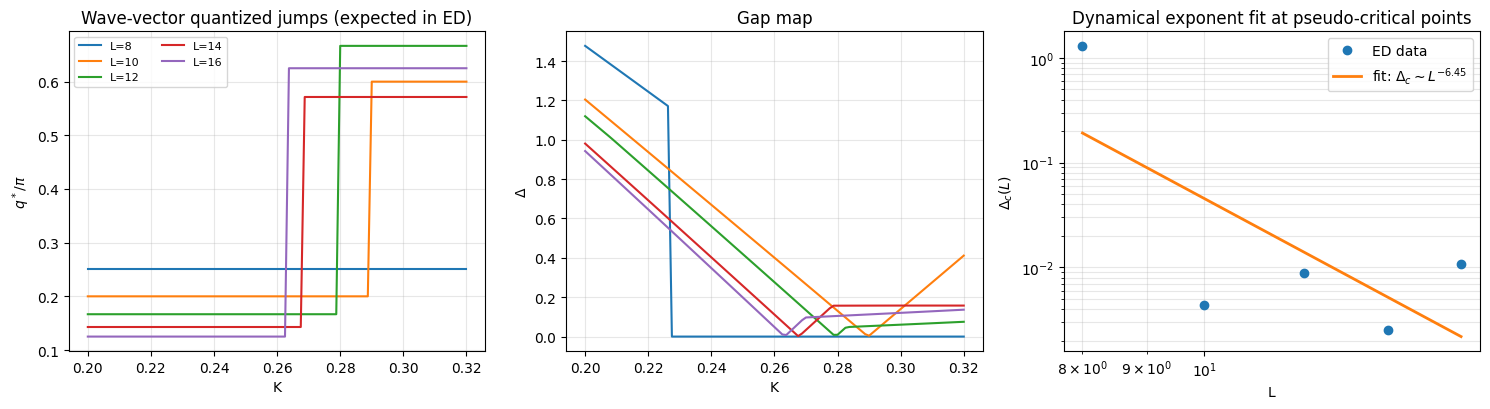

In [29]:
# --- Robust ED extraction of z at the Lifshitz/PT candidate ---
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

J = 1.0
h = 0.1
L_list = np.array([8, 10, 12, 14, 16])
K_grid = np.linspace(0.20, 0.32, 97)   # refine around your jump

def first_nondegenerate_gap(E, tol=1e-8):
    dE = np.real(E) - np.real(E[0])
    idx = np.where(dE > tol)[0]
    return dE[idx[0]] if len(idx) else np.nan

def sz_table_from_basis_states(states, L):
    bits = ((states[:, None] >> np.arange(L)) & 1).astype(np.int8)
    return bits - 0.5

def Szz_of_q(psi0, basis, L):
    p = np.abs(psi0) ** 2
    sz = sz_table_from_basis_states(basis.states, L)
    mz = p @ sz
    mbar = np.mean(mz)
    C = np.zeros(L, dtype=float)
    for r in range(L):
        C[r] = np.mean(p @ (sz * np.roll(sz, -r, axis=1))) - mbar**2
    q = 2 * np.pi * np.arange(L) / L
    S = np.real(np.fft.fft(C))
    return q, S

gap_map = np.full((len(L_list), len(K_grid)), np.nan)
qstar_map = np.full_like(gap_map, np.nan)

for iL, L in enumerate(tqdm(L_list, desc="sizes")):
    for iK, k in enumerate(K_grid):
        # requires your function to support n_eigs>2 and return sorted (E,V,basis)
        E, V, basis = exact_diagonalization_lengths(int(L), (J, h, float(k)), n_eigs=12)

        gap_map[iL, iK] = first_nondegenerate_gap(E, tol=1e-8)

        psi0 = V[:, 0]
        q, S = Szz_of_q(psi0, basis, int(L))
        i_peak = np.argmax(S[1:int(L)//2 + 1]) + 1
        qstar_map[iL, iK] = q[i_peak]

# pseudo-critical Kc(L) from largest |dq*/dK|
KcL = np.full(len(L_list), np.nan)
Delta_c = np.full(len(L_list), np.nan)

for iL, L in enumerate(L_list):
    dq = np.gradient(qstar_map[iL], K_grid)
    idx = np.argmax(np.abs(dq))
    KcL[iL] = K_grid[idx]
    Delta_c[iL] = gap_map[iL, idx]

# fit Delta_c(L) ~ L^{-z}
m = np.isfinite(Delta_c) & (Delta_c > 0)
x = np.log(L_list[m].astype(float))
y = np.log(Delta_c[m])

coef, cov = np.polyfit(x, y, 1, cov=True)
z = -coef[0]
z_err = np.sqrt(max(cov[0, 0], 0.0))
print(f"z = {z:.3f} ± {z_err:.3f}")

# --- Plots ---
fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))

for iL, L in enumerate(L_list):
    ax[0].plot(K_grid, qstar_map[iL]/np.pi, "-", lw=1.5, label=f"L={L}")
ax[0].set_xlabel("K")
ax[0].set_ylabel(r"$q^*/\pi$")
ax[0].set_title("Wave-vector quantized jumps (expected in ED)")
ax[0].grid(alpha=0.3)
ax[0].legend(fontsize=8, ncol=2)

for iL, L in enumerate(L_list):
    ax[1].plot(K_grid, gap_map[iL], "-", lw=1.5, label=f"L={L}")
ax[1].set_xlabel("K")
ax[1].set_ylabel(r"$\Delta$")
ax[1].set_title("Gap map")
ax[1].grid(alpha=0.3)

ax[2].plot(L_list[m], Delta_c[m], "o", ms=6, label="ED data")
Lfit = np.linspace(L_list[m].min(), L_list[m].max(), 200)
ax[2].plot(Lfit, np.exp(np.polyval(coef, np.log(Lfit))), "-", lw=2,
           label=rf"fit: $\Delta_c \sim L^{{-{z:.2f}}}$")
ax[2].set_xscale("log")
ax[2].set_yscale("log")
ax[2].set_xlabel("L")
ax[2].set_ylabel(r"$\Delta_c(L)$")
ax[2].set_title("Dynamical exponent fit at pseudo-critical points")
ax[2].grid(alpha=0.3, which="both")
ax[2].legend()

plt.tight_layout()
plt.show()


## Magnetization Profile

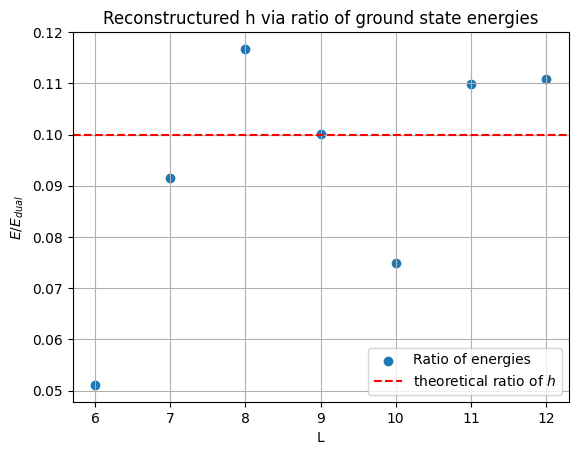

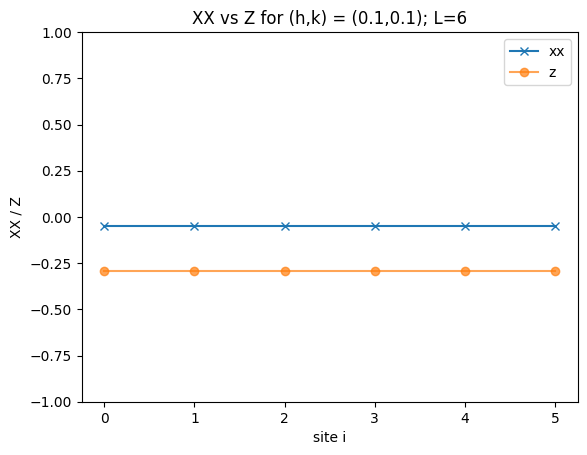

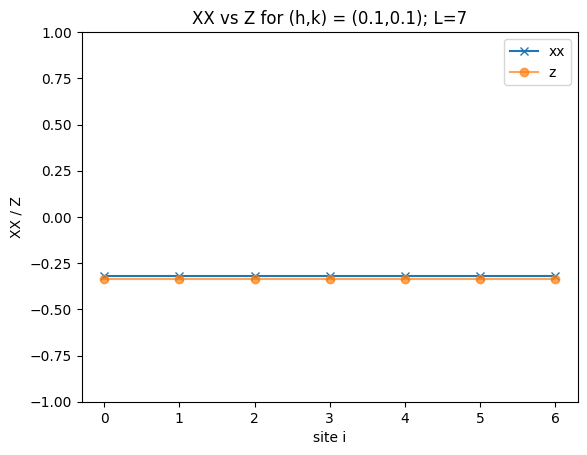

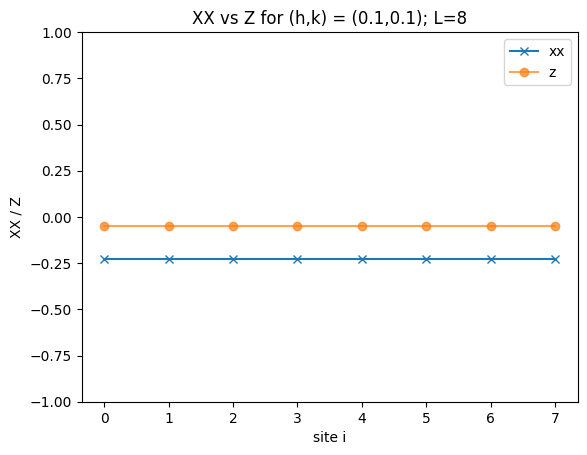

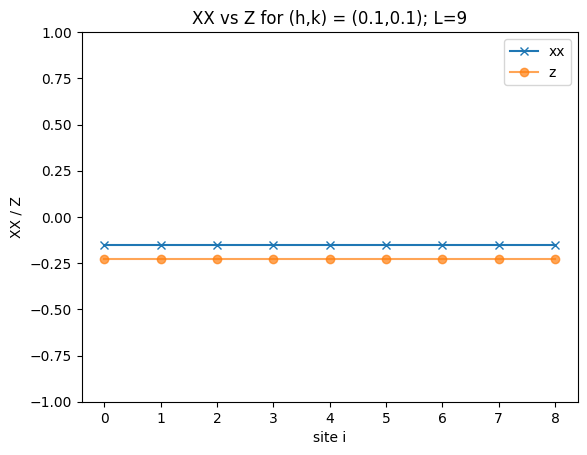

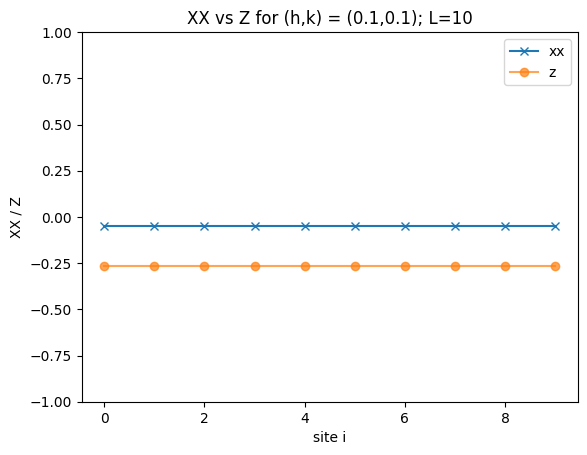

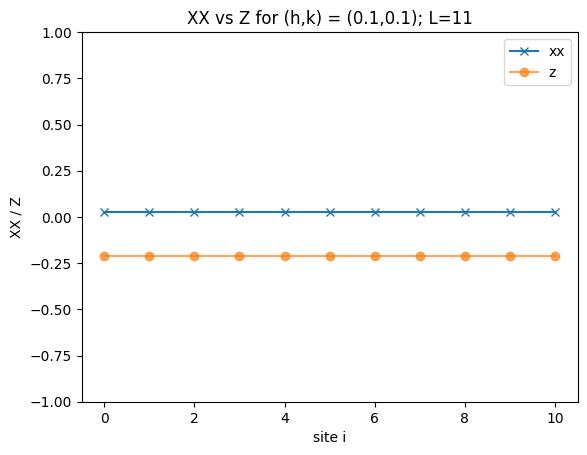

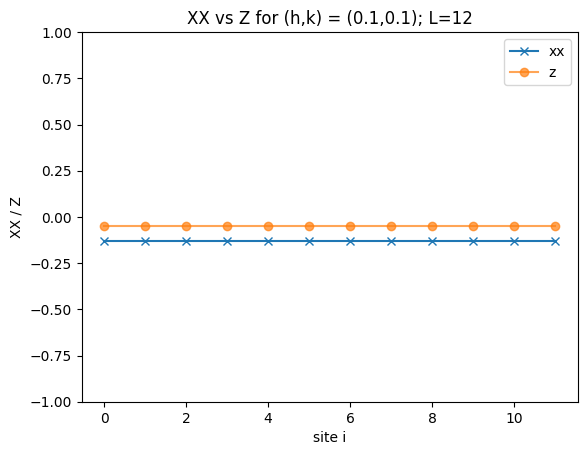

In [ ]:
def magnetization_string(op, psi, dist=1):
    """
    Measure <op_i op_{i+dist} ...> on even (regular) or odd (dual) sites.
    The basis is inferred from the size of psi.
    """

    # infer active lattice size
    L_active = int(np.log2(psi.size))
    basis = spin_basis_1d(L_active)

    # determine site mapping
    start = 0
    step = 1

    active_sites = list(range(start, L_active, step))
    idx_map = {site: i for i, site in enumerate(active_sites)}

    n_ops = len(op)
    values = []

    for i in active_sites:
        # reindex sites to 0..L_active-1
        indices = [idx_map[(i + j*dist) % L_active] for j in range(n_ops)]

        static = [
            [op, [[1.0, *indices]]]
        ]
        operator = quantum_LinearOperator(
            static,
            basis=basis,
            check_symm=False,
            check_herm=False,
            dtype=np.complex128,
        )

        val = operator.expt_value(psi)
        values.append(np.real(val))

    return np.array(values)

results = os.path.join(os.getcwd(), f"ed_lengths/{J}-{h}-{k}")

energies_dual = np.loadtxt(os.path.join(results+"-dual", "energies")).T
energies = np.loadtxt(os.path.join(results+"", "energies")).T
reconstructed_h = energies/energies_dual

plt.title("Reconstructured h via ratio of ground state energies")
plt.scatter(L, reconstructed_h, label="Ratio of energies")
plt.axhline(np.abs(h), c="red",ls = "--", label=r"theoretical ratio of $h$")
plt.legend()
plt.grid()
plt.xlabel("L")
plt.ylabel(r"$E / E_{dual}$")
plt.show()

XX_bulk = []
Z_bulk = []

files = [
    f for f in os.listdir(results)
    if f != "energies"
]

# Sort based on l, which is the integer before the underscore
files.sort(key=lambda x: int(x.split("_")[0][1:]))

for i in files:
    if i == "energies":
        continue
    l = int(i.split("_")[0][1:])

    psi = np.load(os.path.join(results,i))
    psi_dual = np.load(os.path.join(results+"-dual", i))

    sites = np.arange(0, l, 1)

    XX = magnetization_string("xx", psi_dual, dist=1)
    Z  = magnetization_string("z", psi, dist=1)

    XX_bulk.append(np.mean(XX[1:-1]))
    Z_bulk.append(np.mean(Z[1:-1]))

    plt.plot(sites, XX, marker="x", label="xx")
    plt.plot(sites, Z, marker="o", alpha=0.7, label="z")

    plt.ylim(-1, 1)
    plt.title(f"XX vs Z for (h,k) = ({h},{k}); L={l}")
    plt.xlabel("site i")
    plt.ylabel("XX / Z")
    plt.legend()
    plt.show()

/tmp/ipykernel_10975/1961600287.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


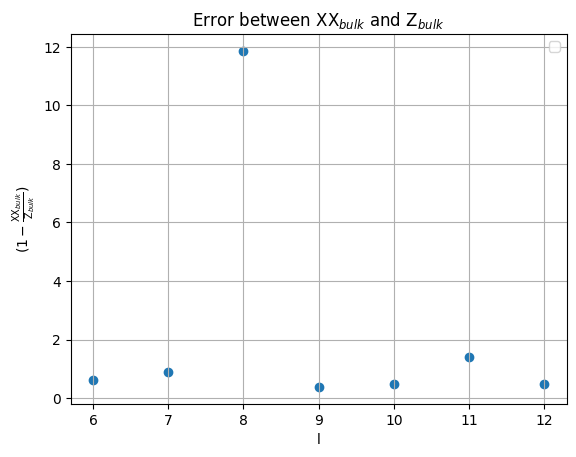

In [ ]:
from scipy.optimize import curve_fit

odd_sites = L

def line(x, a, b):
    return a*x + b
popt, pcov = curve_fit(line, odd_sites, (1-np.array(XX_bulk)/np.array(Z_bulk)))
# plt.plot(1/odd_sites, line(odd_sites, *popt))

# plt.axhline(0, c="red", ls="--",label="Duality")
plt.scatter(odd_sites, np.abs(1-np.abs(np.array(XX_bulk)/np.array(Z_bulk))))

plt.title(r"Error between $\text{XX}_{bulk}$ and $\text{Z}_{bulk}$")
plt.xlabel(r"l")
plt.ylabel(r"$(1 - \frac{\text{XX}_{bulk}}{\text{Z}_{bulk}})$")

plt.grid()
plt.legend()
plt.show()

# plt.scatter(odd_sites, (1-np.array(XX_bulk)/np.array(Z_bulk)), label=f"{popt}")
# plt.plot(odd_sites, (popt[1] + odd_sites*popt[0]))
# plt.show()
# plt.plot(odd_sites, 2/odd_sites)

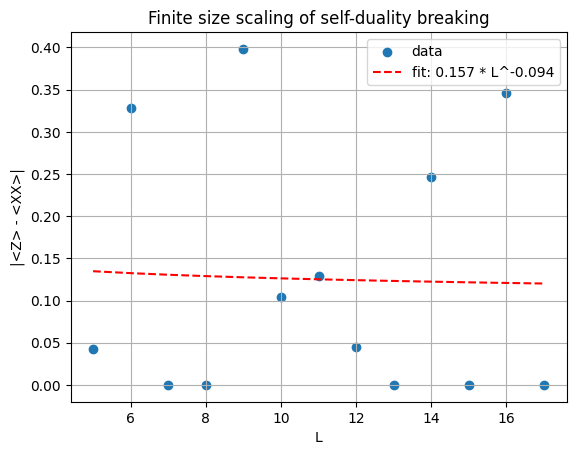

Power law exponent: -0.094


In [ ]:
diff = np.abs(np.array(Z_bulk) - np.array(XX_bulk))

def power_law(x, a, alpha):
    return a * x**alpha

popt, pcov = curve_fit(power_law, odd_sites, diff)

plt.scatter(odd_sites, diff, label='data')
plt.plot(odd_sites, power_law(odd_sites, *popt), 'r--', 
         label=f'fit: {popt[0]:.3f} * L^{popt[1]:.3f}')
plt.xlabel('L')
plt.ylabel('|<Z> - <XX>|')
plt.title('Finite size scaling of self-duality breaking')
plt.legend()
plt.grid()
plt.show()

print(f"Power law exponent: {popt[1]:.3f}")

In [ ]:
for i in range(len(L)):
    err =1-(Z_bulk[i] / XX_bulk[i])
    print(np.log10(np.abs(err)))

-14.750469787535078
-14.449439791871097
-14.539616422220185
-14.273348532815415
-0.5891780914880838
-0.6276325696136842


## Entanglement

21it [00:00, 65.73it/s]


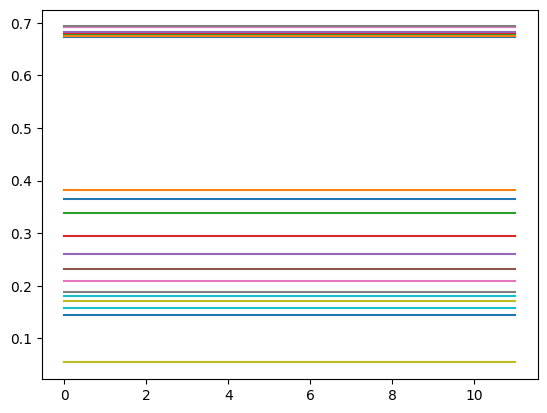

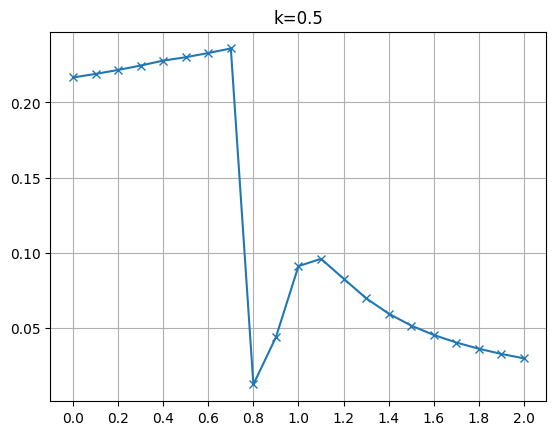

[0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7
 1.8 1.9 2. ]


In [ ]:
# results = f"ed_results/L{L}_{opp}{set}_{scan_var}{np.min(values)}-{np.max(values)}_states1"
var_num = len(values)
def entanglement_site(psi, basis):
    L = int(np.log2(len(psi)))
    mid = list(range(L//2))
    ent_mid = basis.ent_entropy(psi, sub_sys_A=mid)["Sent_A"]
    return ent_mid

def entanglement_string(psi, basis):
    s_sites = []
    L = int(np.log2(len(psi)))

    for i in range(L):
        ent = basis.ent_entropy(psi, sub_sys_A=[i])
        s_sites.append(ent["Sent_A"])

    return s_sites

# --- entropy ---
single_site_entropy_curves = []
half_chain_entropy = []


for ind, i in tqdm(enumerate(sorted(os.listdir(results)))):
    psi = np.load(os.path.join(results,i))
    
    #--- Entanglement---
    single_site_entropy_curves.append(entanglement_site(psi, basis))
    half_chain_entropy = entanglement_string(psi, basis)
    plt.plot(half_chain_entropy, label=f"{i}")
# plt.legend()
plt.show()
plt.grid()
plt.title(f"{opp}={set}")
plt.xticks(values[::2])
plt.plot(values, single_site_entropy_curves, marker="x")
plt.show()
print(values)


## Correlator

41it [00:00, 399.80it/s]


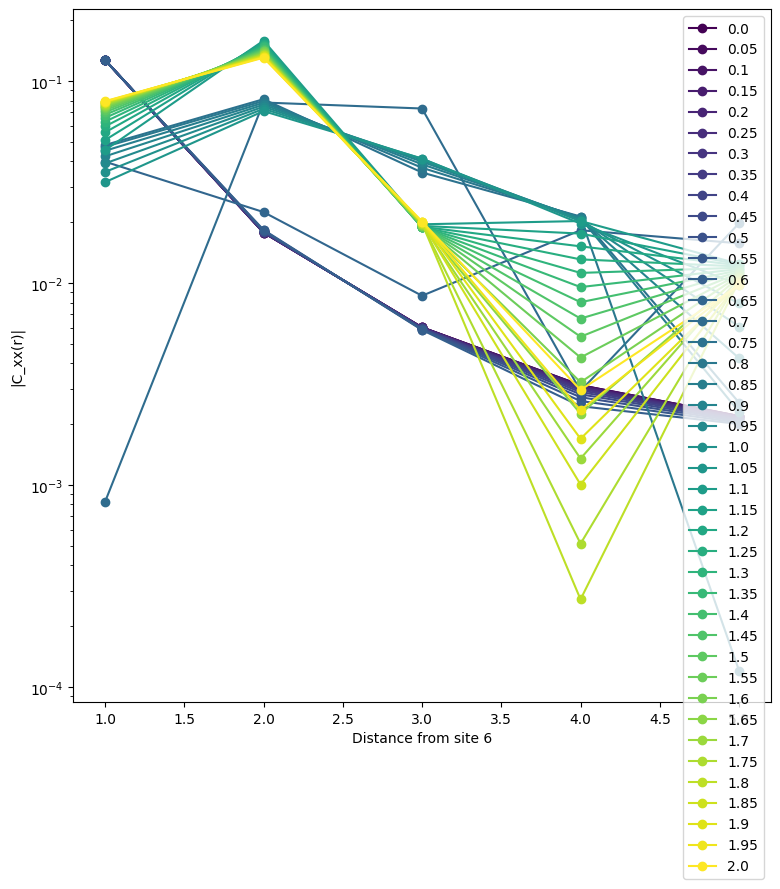

In [ ]:
def correlator(op1, op2, i, j, psi, basis, dist=1):
    '''Connected correlator: g(op1, op2) = <op1_i op2_j> - <op1_i><op2_j>'''
    positions_i = [(i+dist*x)%L for x in range(len(op1))]
    positions_j = [(j+dist*y)%L for y in range(len(op2))]

    operators = [[op1+op2, [[1.0] + positions_i + positions_j]]]
    # print(operators)
    corr_op = quantum_LinearOperator(operators, basis=basis, check_symm=False, check_herm=False, dtype=np.complex128)
    corr = corr_op.expt_value(psi)
    
    op_i = quantum_LinearOperator([[op1, [[1.0] + positions_i]]], basis=basis, check_symm=False, check_herm=False, dtype=np.complex128)
    exp_i = op_i.expt_value(psi)
    
    op_j = quantum_LinearOperator([[op2, [[1.0] + positions_j]]], basis=basis, check_symm=False, check_herm=False, dtype=np.complex128)
    exp_j = op_j.expt_value(psi)

    connected_correlator = corr - (exp_i * exp_j)
    return connected_correlator

def correlator_string(op1, op2, psi, basis, reference_site=None, bc="pbc"):
    '''Calculate correlations from one reference site to all other sites'''
    L = basis.N
    
    # Use middle site as default reference to minimize boundary effects
    if reference_site is None:
        reference_site = 0
    
    distances = []
    correlations = []
    
    for j in range(L):
        if j <= reference_site:
            continue  # Skip self-correlation
            
        if bc == "pbc":
            # For PBC, use minimum image convention
            dist = min(abs(j - reference_site), L - abs(j - reference_site))
            dist = abs(j - reference_site)
        else:
            dist = abs(j - reference_site)
            
        corr_val = correlator(op1, op2, reference_site, j, psi, basis)
        
        distances.append(dist)
        correlations.append(corr_val)
    
    return distances, correlations

# Usage - pick one consistent reference site
reference_site = L//2  # Middle of the chain
plt.figure(figsize=(9,9))

col = plt.cm.viridis(np.linspace(0, 1, 41))

for ind, filename in tqdm(enumerate(sorted(os.listdir(results)))):
    psi = np.load(os.path.join(results, filename))
    
    # Calculate correlations from the same reference site for all states
    distance, corr = correlator_string("z", "z", psi, basis, reference_site=reference_site, bc="pbc")
    tag = float(filename.split("_")[2])
    plt.semilogy(distance, np.abs(corr),'o-', label=f"{tag}",color=col[ind])

plt.xlabel(f'Distance from site {reference_site}')
plt.ylabel('|C_xx(r)|')
plt.legend()
plt.show()

## Central Charge

0it [00:00, ?it/s]/tmp/ipykernel_75188/1857814191.py:63: RuntimeWarning: divide by zero encountered in log
  x0 = np.log((L/np.pi) * np.sin(np.pi * positions / L))  # linearize
/tmp/ipykernel_75188/1857814191.py:66: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(s_calabrese_cardy, x0[1:L//2+1], S[1:L//2+1])


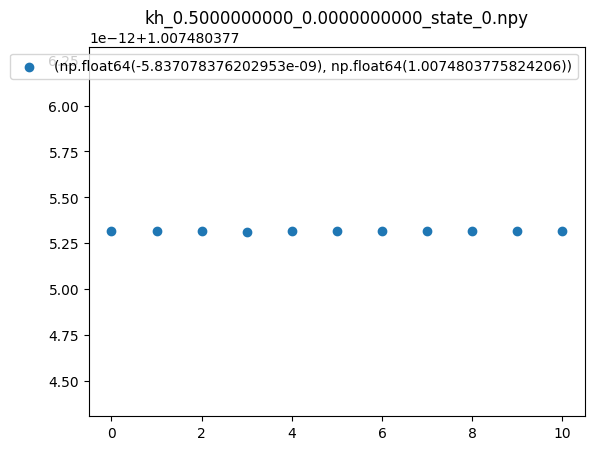

1it [00:00,  4.48it/s]

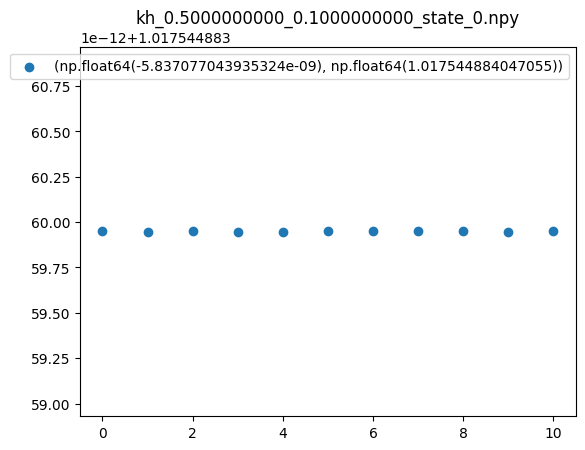

2it [00:00,  4.97it/s]

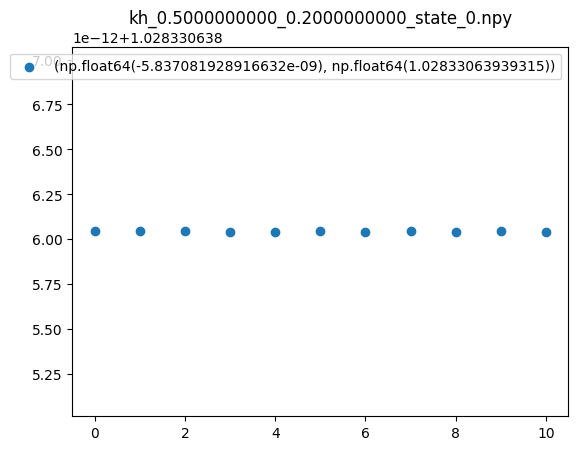

3it [00:00,  4.82it/s]

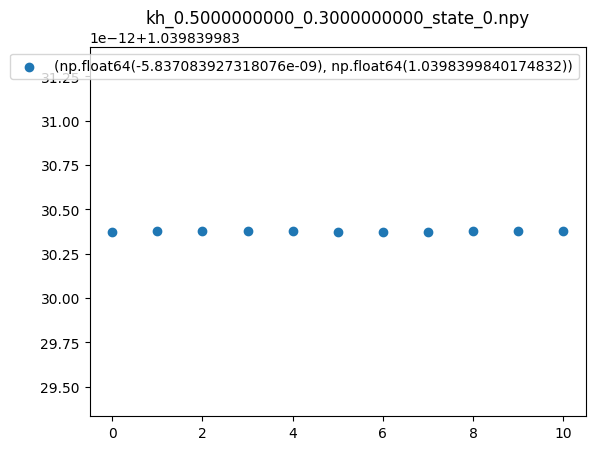

4it [00:00,  5.05it/s]

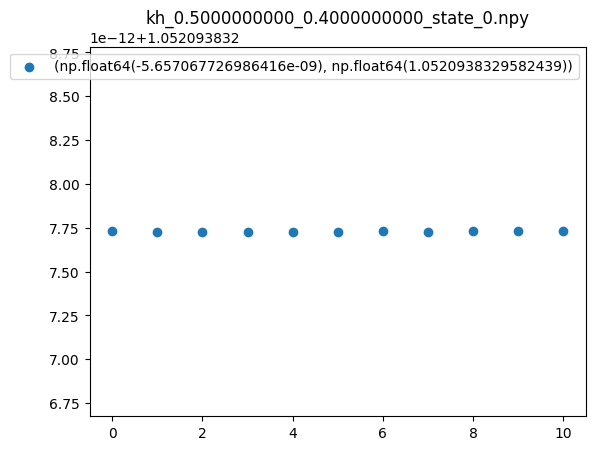

5it [00:01,  4.74it/s]

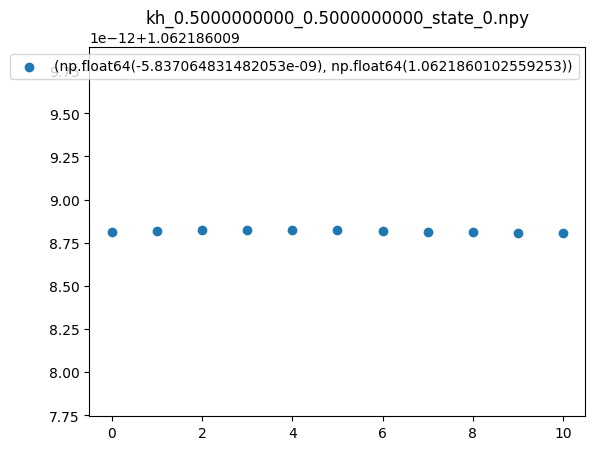

6it [00:01,  4.96it/s]

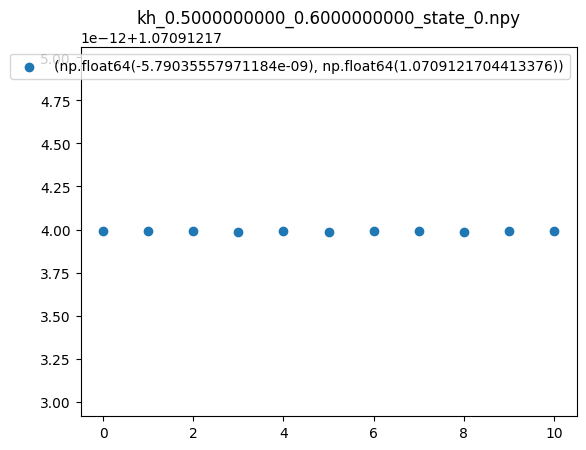

7it [00:01,  4.95it/s]

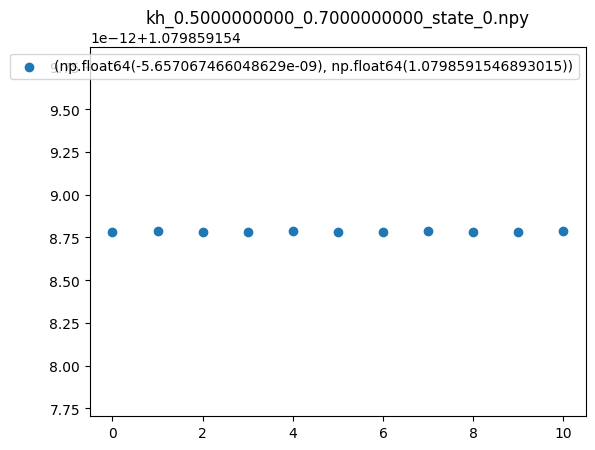

8it [00:01,  4.90it/s]

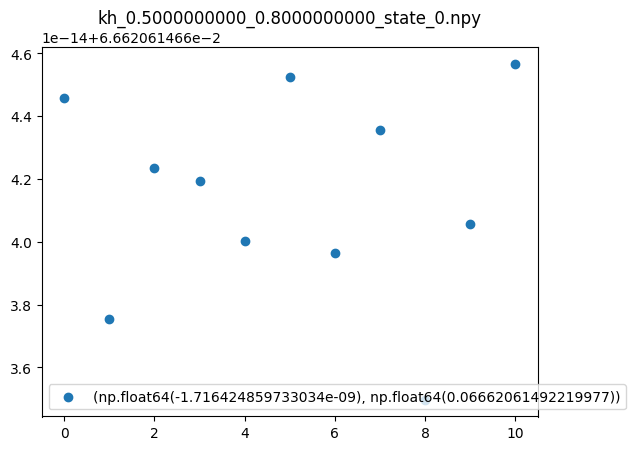

9it [00:01,  4.06it/s]

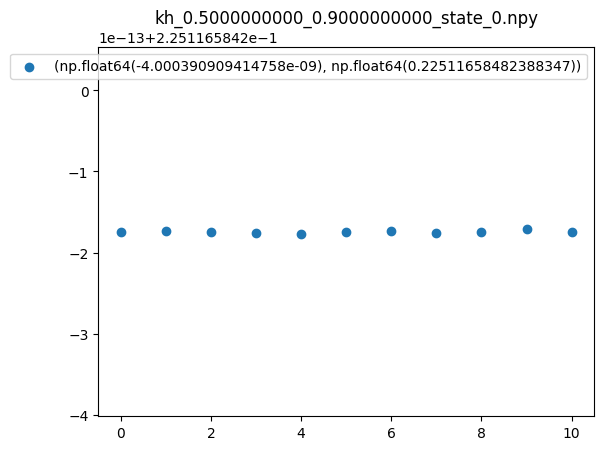

10it [00:02,  4.20it/s]

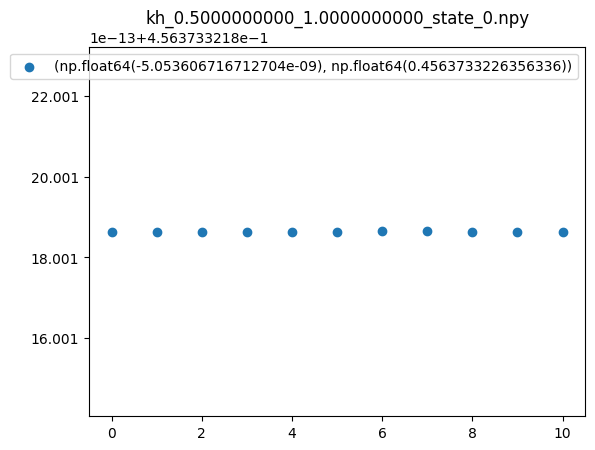

11it [00:02,  4.19it/s]

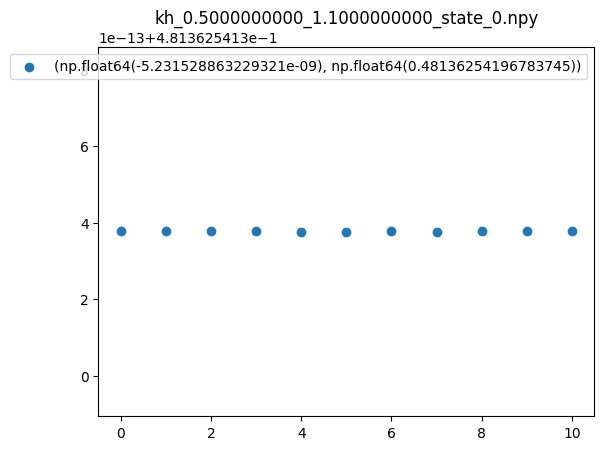

12it [00:02,  4.06it/s]

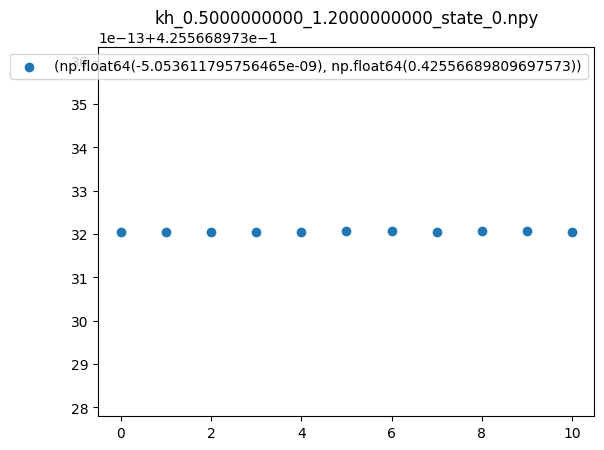

13it [00:02,  3.91it/s]

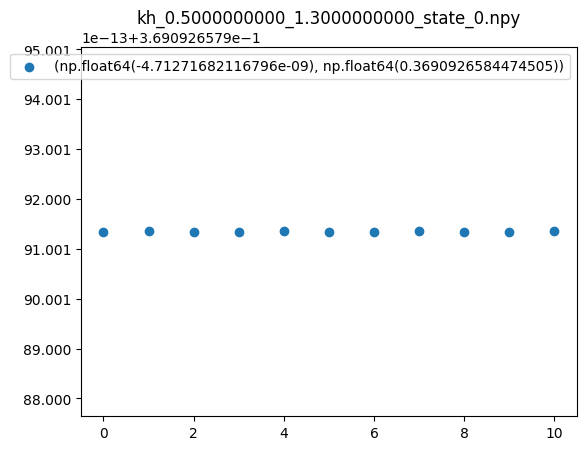

14it [00:03,  3.93it/s]

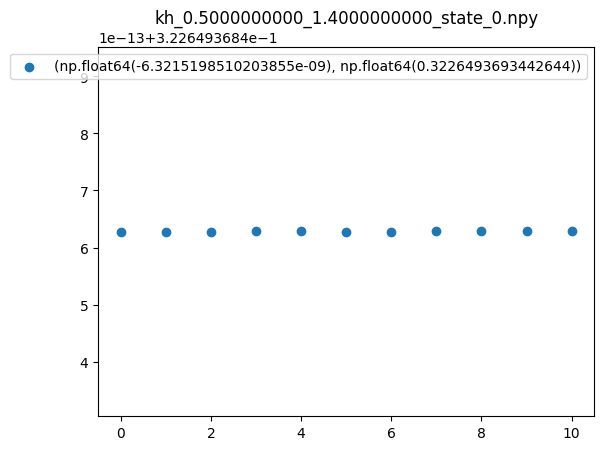

15it [00:03,  3.99it/s]

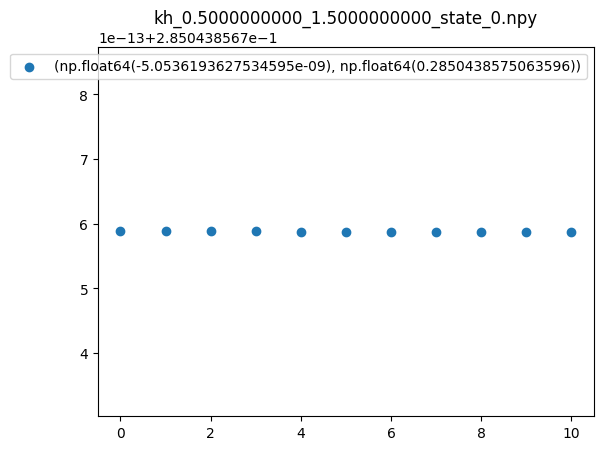

16it [00:03,  4.03it/s]

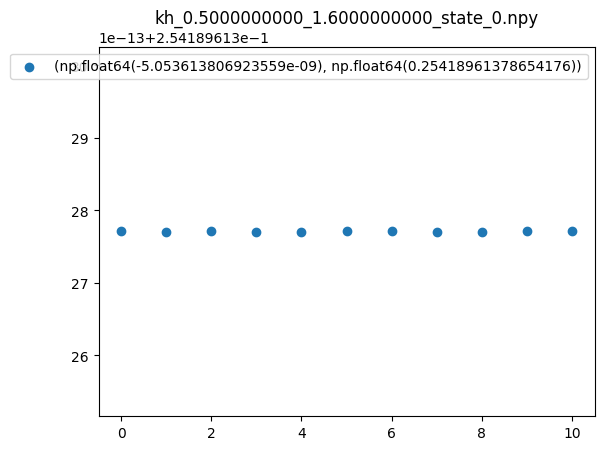

17it [00:03,  3.94it/s]

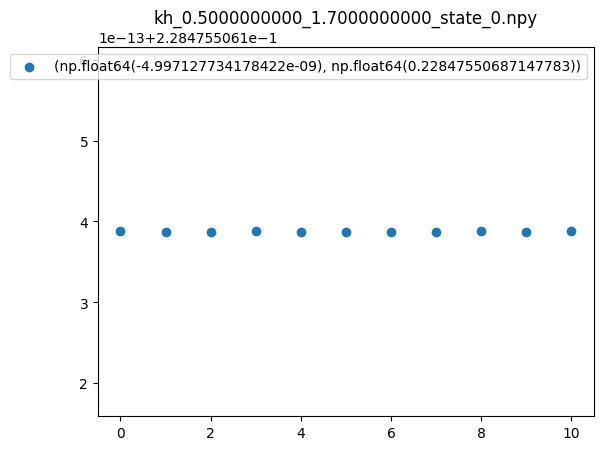

18it [00:04,  4.28it/s]

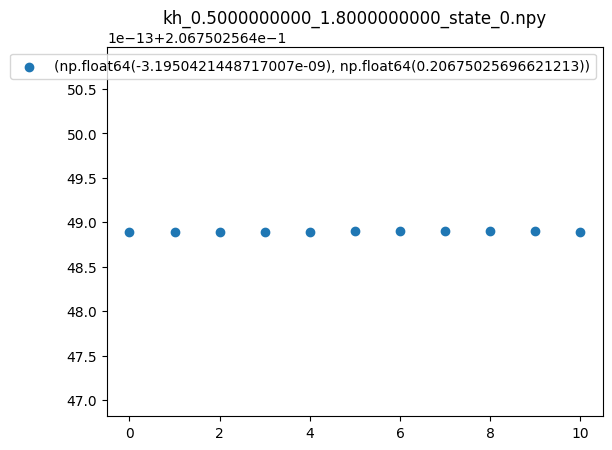

19it [00:04,  4.48it/s]

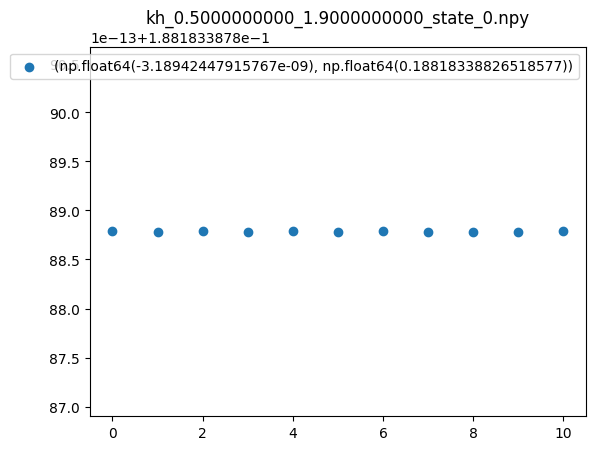

20it [00:04,  4.71it/s]

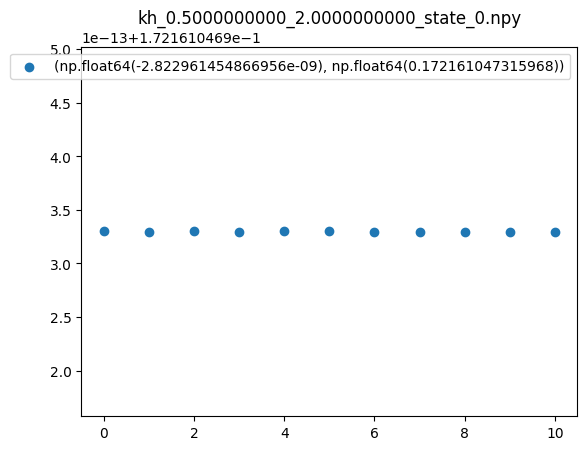

21it [00:04,  4.39it/s]


In [ ]:
from scipy.optimize import curve_fit

# Calculate central charge
# results = f"ed_results/L{L}_{opp}{set}_{scan_var}{np.min(values)}-{np.max(values)}_states"

def bond_entanglement_entropy(psi, basis, site_i, site_j):
    """
    Calculate entanglement entropy between two sites i and j.
    
    Parameters:
    psi: ground state wavefunction
    basis: QuSpin basis object
    site_i, site_j: indices of the two sites (should be neighbors for S(i,i+1))
    
    Returns:
    S: von Neumann entanglement entropy between sites i and j
    """
    # Create list of sites for the reduced density matrix
    sites = [site_i, site_j]
    rho_ij = basis.partial_trace(psi, sites)
    eigvals = np.linalg.eigvalsh(rho_ij)
    eigvals = eigvals[eigvals > 1e-15]
    S = -np.sum(eigvals * np.log(eigvals))
    
    return S

def all_bond_entropies(psi, basis, L):
    """
    Calculate S(i,i+1) for all bonds in the chain.
    
    Returns:
    positions: bond positions (center between sites)
    entropies: S(i,i+1) values
    """
    positions = []
    entropies = []
    
    for i in range(L-1):  # For open boundaries
        S = bond_entanglement_entropy(psi, basis, i, i+1)
        positions.append(i)  # Bond center
        entropies.append(S)
    
    return np.array(positions), np.array(entropies)

def s_calabrese_cardy(x, c, s0):
    return (c/6) * x + s0

# def s_calabrese_cardy(x, c, s0):
#     return (c/6) * np.log((L/np.pi) * np.sin(np.pi * x / L)) + s0

for ind, i in tqdm(enumerate(sorted(os.listdir(results), key= lambda x: float(x.split("_")[2])))):
    psi = np.load(os.path.join(results,i))
    positions, S = all_bond_entropies(psi, basis, L)

    x0 = np.log((L/np.pi) * np.sin(np.pi * positions / L))  # linearize

    # fit
    popt, pcov = curve_fit(s_calabrese_cardy, x0[1:L//2+1], S[1:L//2+1])

    plt.scatter(positions, S, label=f"{popt[0], popt[1]}")
    # plt.plot(positions, s_calabrese_cardy(positions, *popt))
    plt.title(f"{i}")
    plt.legend()
    plt.show()

## Manual ED

In [ ]:
# doApplyHam.py

import numpy as np

def doApplyHam2(psiIn, hloc2, N, usePBC):
    """Applies 2-site local Hamiltonian terms."""
    d = hloc2.shape[0]
    psiOut = np.zeros(psiIn.size, dtype=complex)

    for k in range(N - 1):
        psiOut += np.tensordot(hloc2.reshape(d**2, d**2),
                               psiIn.reshape(d**k, d**2, d**(N - 2 - k)),
                               axes=[[1], [1]]).transpose(1, 0, 2).reshape(d**N)

    if usePBC:
        psiOut += np.tensordot(hloc2.reshape(d, d, d, d),
                               psiIn.reshape(d, d**(N - 2), d),
                               axes=[[2, 3], [2, 0]]
                               ).transpose(1, 2, 0).reshape(d**N)
    return psiOut


def doApplyHam3(psiIn, hloc3, N, usePBC):
    """Applies 3-site local Hamiltonian terms."""
    d = hloc3.shape[0]
    psiOut = np.zeros(psiIn.size, dtype=complex)
    hloc_mat = hloc3.reshape(d**3, d**3)

    for k in range(N - 2):
        psiOut += np.tensordot(hloc_mat,
                               psiIn.reshape(d**k, d**3, d**(N - 3 - k)),
                               axes=[[1], [1]]).transpose(1, 0, 2).reshape(d**N)

    if usePBC:
        psi = psiIn.reshape([d] * N)
        for sites in [[N-2, N-1, 0], [N-1, 0, 1]]:
            rest = [s for s in range(N) if s not in sites]
            psi_T = np.transpose(psi, sites + rest).reshape(d**3, d**(N-3))
            psi_T = (hloc_mat @ psi_T).reshape([d]*3 + [d]*(N-3))
            psiOut += np.transpose(psi_T, np.argsort(sites + rest)).reshape(d**N)

    return psiOut

In [ ]:
# mainExactDiag.py

import numpy as np
from scipy.sparse.linalg import LinearOperator, eigsh
from timeit import default_timer as timer

# Simulation parameters
Nsites = 9
usePBC = False
numval = 4

d = 2
sX = np.array([[0, 1], [1.0, 0]])
sY = np.array([[0, -1.0j], [1.0j, 0]])
sZ = np.array([[1.0, 0], [0, -1.0]])
sI = np.array([[1.0, 0], [0, 1.0]])

J = 1.0
h = 0.5
k = 0

# 2-site hloc: XX interaction + Z field split evenly over bonds
hloc2 = (J * np.kron(sX, sX)
         + h/2 * (np.kron(sZ, sI) + np.kron(sI, sZ))
         ).reshape(2, 2, 2, 2)

# 3-site hloc: k terms only
XIY = np.kron(np.kron(sX, sI), sY)
YIX = np.kron(np.kron(sY, sI), sX)
XYZ = np.kron(np.kron(sX, sY), sZ)
ZYX = np.kron(np.kron(sZ, sY), sX)

hloc3 = (-k * (XIY - YIX + XYZ - ZYX)).reshape(2, 2, 2, 2, 2, 2)

def doApplyHamClosed(psiIn):
    return doApplyHam2(psiIn, hloc2, Nsites, usePBC) + doApplyHam3(psiIn, hloc3, Nsites, usePBC)

H = LinearOperator((2**Nsites, 2**Nsites), matvec=doApplyHamClosed)

start_time = timer()
Energy, psi = eigsh(H, k=numval, which='SA')
print("Low-lying spectrum:", Energy)
print("Gaps:", np.diff(Energy))
diag_time = timer() - start_time

print('NumSites: %d, Time: %1.2f s, Energy: %e' % (Nsites, diag_time, Energy[0]))

# measurements
def expect_single(psi, op, i, N):
    d = op.shape[0]
    psi = psi.reshape([d]*N)
    psi_op = np.tensordot(op, psi, axes=[[1],[i]])
    psi_op = np.moveaxis(psi_op, 0, i)
    return np.real(np.dot(psi.conj().reshape(-1), psi_op.reshape(-1)))

def expect_two(psi, op1, op2, i, j, N):
    d = op1.shape[0]
    psi = psi.reshape([d]*N)
    psi_op = np.tensordot(op2, psi, axes=[[1],[j]])
    psi_op = np.moveaxis(psi_op, 0, j)
    psi_op = np.tensordot(op1, psi_op, axes=[[1],[i]])
    psi_op = np.moveaxis(psi_op, 0, i)
    return np.real(np.dot(psi.conj().reshape(-1), psi_op.reshape(-1)))

psi0 = psi[:, 0]
Z_vals  = np.array([expect_single(psi0, sZ, i, Nsites) for i in range(Nsites)])
XX_vals = np.array([expect_two(psi0, sX, sX, i, (i+1)%Nsites, Nsites) for i in range(Nsites)])
print("Parameters (J, h, k)", J, h, k)
print("mean <Z>:        ", np.round(np.mean(Z_vals), 6))
print("mean <X_i X_i+1>:", np.round(np.mean(XX_vals), 6))
print("difference:      ", np.round(np.mean(Z_vals)-np.mean(XX_vals), 6))

Low-lying spectrum: [-8.51116371 -8.51026226 -7.40134493 -7.40224638]
Gaps: [ 9.01445213e-04  1.10891733e+00 -9.01445213e-04]
NumSites: 9, Time: 1.90 s, Energy: -8.511164e+00
Parameters (J, h, k) 1.0 0.5 0
mean <Z>:         -0.263008
mean <X_i X_i+1>: -0.726726
difference:       0.463718


In [ ]:
for L in [6, 9, 12, 15]:
    Nsites = L
    hloc2 = (-J * np.kron(sX, sX)
             - h/2 * (np.kron(sZ, sI) + np.kron(sI, sZ))
             ).reshape(2, 2, 2, 2)
    hloc3 = (k * (XIY - YIX + XYZ - ZYX)).reshape(2, 2, 2, 2, 2, 2)

    def doApplyHamClosed(psiIn):
        return doApplyHam2(psiIn, hloc2, Nsites, usePBC) + doApplyHam3(psiIn, hloc3, Nsites, usePBC)

    H = LinearOperator((2**Nsites, 2**Nsites), matvec=doApplyHamClosed)
    Energy, psi = eigsh(H, k=4, which='SA')
    gap = Energy[1] - Energy[0]
    print(f"L={L}  E0={Energy[0]:.4f}  gap={gap:.6f}  E/L={Energy[0]/L:.4f}")

L=6  E0=-52.0027  gap=3.381388  E/L=-8.6671
L=9  E0=-76.0647  gap=0.525697  E/L=-8.4516
L=12  E0=-101.7431  gap=1.978462  E/L=-8.4786
L=15  E0=-127.1050  gap=0.204496  E/L=-8.4737



L=6
  k=0.00  gap=0.2633  E/L=-1.2879  <Z>=0.6440  <XX>=0.6440  diff=0.0000
  k=0.17  gap=0.2630  E/L=-1.2879  <Z>=0.6440  <XX>=0.6440  diff=0.0000
  k=0.34  gap=0.4118  E/L=-1.3565  <Z>=0.6133  <XX>=0.2841  diff=0.3293
  k=0.52  gap=0.9183  E/L=-1.5886  <Z>=0.6055  <XX>=0.2800  diff=0.3255
  k=0.69  gap=0.7151  E/L=-1.8249  <Z>=0.5969  <XX>=0.2757  diff=0.3212
  k=0.86  gap=0.5205  E/L=-2.0645  <Z>=0.5880  <XX>=0.2714  diff=0.3166
  k=1.03  gap=0.3329  E/L=-2.3067  <Z>=0.5792  <XX>=0.2672  diff=0.3120
  k=1.21  gap=-0.1510  E/L=-2.5259  <Z>=0.2998  <XX>=0.2998  diff=0.0000
  k=1.38  gap=-0.0262  E/L=-2.7971  <Z>=0.5630  <XX>=0.2596  diff=0.3034
  k=1.55  gap=0.1997  E/L=-3.0779  <Z>=0.2937  <XX>=0.2937  diff=0.0000
  k=1.72  gap=0.3701  E/L=-3.3549  <Z>=0.2910  <XX>=0.2910  diff=0.0000
  k=1.90  gap=0.5380  E/L=-3.6324  <Z>=0.2885  <XX>=0.2885  diff=0.0000
  k=2.07  gap=0.7038  E/L=-3.9104  <Z>=0.2862  <XX>=0.2862  diff=0.0000
  k=2.24  gap=0.8678  E/L=-4.1887  <Z>=0.2841  <XX>=0.284

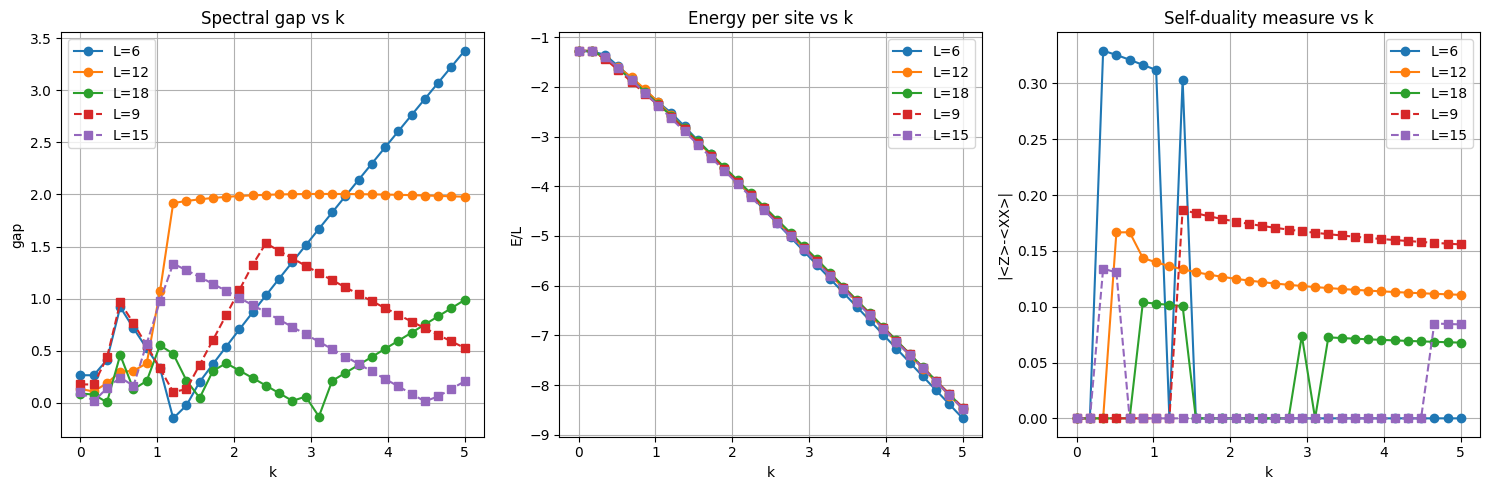

In [ ]:
import numpy as np
from scipy.sparse.linalg import LinearOperator, eigsh
import matplotlib.pyplot as plt

k_values = np.linspace(0.0, 5.0, 30)
sizes_even = [6, 12, 18]    # multiples of 6
sizes_odd  = [9, 15]        # odd multiples of 3

results = {L: {'k': [], 'gap': [], 'EperL': [], 'Z': [], 'XX': [], 'diff': []} 
           for L in sizes_even + sizes_odd}

J = 1.0
h = 1.0

for L in sizes_even + sizes_odd:
    print(f"\nL={L}")
    for k in k_values:
        hloc2 = (-J * np.kron(sX, sX)
                 - h/2 * (np.kron(sZ, sI) + np.kron(sI, sZ))
                 ).reshape(2, 2, 2, 2)
        hloc3 = (k * (XIY - YIX + XYZ - ZYX)).reshape(2, 2, 2, 2, 2, 2)

        def doApplyHamClosed(psiIn):
            return doApplyHam2(psiIn, hloc2, L, usePBC) + doApplyHam3(psiIn, hloc3, L, usePBC)

        H = LinearOperator((2**L, 2**L), matvec=doApplyHamClosed)
        Energy, psi = eigsh(H, k=4, which='SA')

        psi0 = psi[:, 0]
        gap   = Energy[1] - Energy[0]
        EperL = Energy[0] / L
        Z_mean  = np.mean([expect_single(psi0, sZ,  i, L) for i in range(L)])
        XX_mean = np.mean([expect_two(psi0, sX, sX, i, (i+1)%L, L) for i in range(L)])

        results[L]['k'].append(k)
        results[L]['gap'].append(gap)
        results[L]['EperL'].append(EperL)
        results[L]['Z'].append(Z_mean)
        results[L]['XX'].append(XX_mean)
        results[L]['diff'].append(abs(Z_mean - XX_mean))

        print(f"  k={k:.2f}  gap={gap:.4f}  E/L={EperL:.4f}  <Z>={Z_mean:.4f}  <XX>={XX_mean:.4f}  diff={abs(Z_mean-XX_mean):.4f}")

# --- plot ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for L in sizes_even:
    axes[0].plot(results[L]['k'], results[L]['gap'],  'o-', label=f'L={L}')
    axes[1].plot(results[L]['k'], results[L]['EperL'],'o-', label=f'L={L}')
    axes[2].plot(results[L]['k'], results[L]['diff'], 'o-', label=f'L={L}')

for L in sizes_odd:
    axes[0].plot(results[L]['k'], results[L]['gap'],  's--', label=f'L={L}')
    axes[1].plot(results[L]['k'], results[L]['EperL'],'s--', label=f'L={L}')
    axes[2].plot(results[L]['k'], results[L]['diff'], 's--', label=f'L={L}')

axes[0].set_xlabel('k'); axes[0].set_ylabel('gap');   axes[0].set_title('Spectral gap vs k')
axes[1].set_xlabel('k'); axes[1].set_ylabel('E/L');   axes[1].set_title('Energy per site vs k')
axes[2].set_xlabel('k'); axes[2].set_ylabel('|<Z>-<XX>|'); axes[2].set_title('Self-duality measure vs k')

for ax in axes:
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

KeyboardInterrupt: 

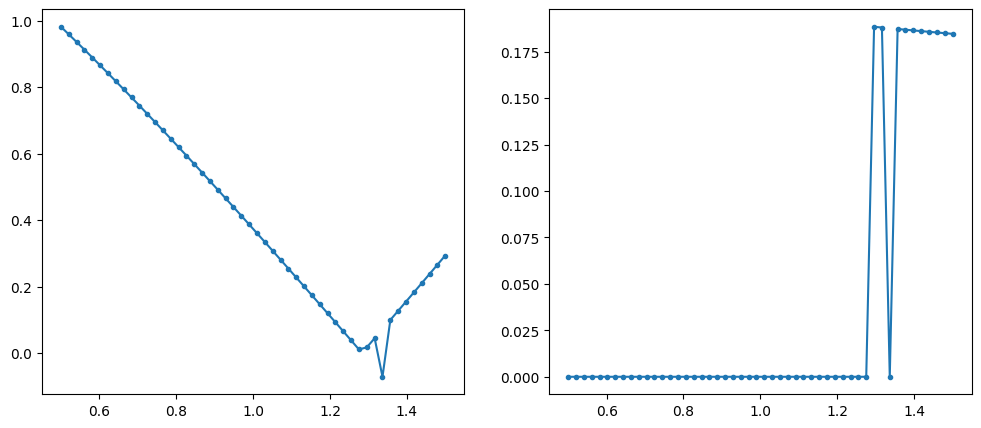

In [ ]:
k_fine = np.linspace(0.5, 1.5, 50)
sizes  = [9, 12, 15, 18]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for L in sizes:
    gaps  = []
    diffs = []
    for k in k_fine:
        hloc2 = (-J * np.kron(sX, sX)
                 - h/2 * (np.kron(sZ, sI) + np.kron(sI, sZ))
                 ).reshape(2, 2, 2, 2)
        hloc3 = (k * (XIY - YIX + XYZ - ZYX)).reshape(2, 2, 2, 2, 2, 2)

        def doApplyHamClosed(psiIn):
            return doApplyHam2(psiIn, hloc2, L, usePBC) + doApplyHam3(psiIn, hloc3, L, usePBC)

        H = LinearOperator((2**L, 2**L), matvec=doApplyHamClosed)
        Energy, psi = eigsh(H, k=4, which='SA')
        psi0 = psi[:, 0]

        gaps.append(Energy[1] - Energy[0])
        Z_mean  = np.mean([expect_single(psi0, sZ,  i, L) for i in range(L)])
        XX_mean = np.mean([expect_two(psi0, sX, sX, i, (i+1)%L, L) for i in range(L)])
        diffs.append(abs(Z_mean - XX_mean))

    axes[0].plot(k_fine, gaps,  'o-', markersize=3, label=f'L={L}')
    axes[1].plot(k_fine, diffs, 'o-', markersize=3, label=f'L={L}')

axes[0].set_xlabel('k'); axes[0].set_ylabel('gap')
axes[0].set_title('Spectral gap (fine scan)'); axes[0].legend(); axes[0].grid(True)
axes[1].set_xlabel('k'); axes[1].set_ylabel('|<Z>-<XX>|')
axes[1].set_title('Self-duality measure (fine scan)'); axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
from scipy.sparse.linalg import LinearOperator, eigsh

def find_self_dual_point(Nsites, J, k, h_range=np.linspace(0.5, 1.5, 51)):
    results = []
    for h_val in h_range:
        hloc2 = (-J * np.kron(sX, sX)
                 - h_val/2 * (np.kron(sZ, sI) + np.kron(sI, sZ))
                 ).reshape(2, 2, 2, 2)
        hloc3 = (k * (XIY - YIX + XYZ - ZYX)).reshape(2, 2, 2, 2, 2, 2)

        def Hclosed(v):
            return doApplyHam2(v, hloc2, Nsites, usePBC) + doApplyHam3(v, hloc3, Nsites, usePBC)

        H = LinearOperator((2**Nsites, 2**Nsites), matvec=Hclosed)
        E, psi = eigsh(H, k=1, which='SA')
        psi0 = psi[:, 0]

        Z_mean  = np.mean([expect_single(psi0, sZ, i, Nsites) for i in range(Nsites)])
        XX_mean = np.mean([expect_two(psi0, sX, sX, i, (i+1)%Nsites, Nsites) for i in range(Nsites)])
        results.append((h_val, Z_mean, XX_mean, abs(Z_mean - XX_mean)))

    # find crossing point
    diffs = [r[3] for r in results]
    best = results[np.argmin(diffs)]
    return best

# scan over system sizes
for L in [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]:
    Nsites = L
    h_star, Z, XX, diff = find_self_dual_point(L, J=1.0, k=5)
    print(f"L={L}  h*={h_star:.4f}  <Z>={Z:.4f}  <XX>={XX:.4f}  diff={diff:.6f}")

L=4  h*=0.5000  <Z>=0.0250  <XX>=-0.0000  diff=0.024969
L=5  h*=0.5000  <Z>=0.4932  <XX>=0.1655  diff=0.327718
L=6  h*=1.0000  <Z>=0.2640  <XX>=0.2640  diff=0.000000
L=7  h*=1.0000  <Z>=0.3370  <XX>=0.3370  diff=0.000000
L=8  h*=1.0000  <Z>=0.4098  <XX>=0.4098  diff=0.000000
L=9  h*=1.5000  <Z>=0.2681  <XX>=0.4195  diff=0.151411
L=10  h*=1.0000  <Z>=0.2477  <XX>=0.2477  diff=0.000000
L=11  h*=0.5000  <Z>=0.2827  <XX>=0.1973  diff=0.085433
L=12  h*=0.5000  <Z>=0.3659  <XX>=0.2675  diff=0.098448
L=13  h*=1.0000  <Z>=0.2910  <XX>=0.2910  diff=0.000000


KeyboardInterrupt: 

ValueError: cannot reshape array of size 262144 into shape (1,4,4096)

In [ ]:
Nsites = 18

def check_hermitian(N, num_trials=20):
    errors = []
    for _ in range(num_trials):
        v1 = np.random.randn(2**N) + 1j*np.random.randn(2**N)
        v2 = np.random.randn(2**N) + 1j*np.random.randn(2**N)
        Hv1 = doApplyHam2(v1, hloc2, N, usePBC) + doApplyHam3(v1, hloc3, N, usePBC)
        Hv2 = doApplyHam2(v2, hloc2, N, usePBC) + doApplyHam3(v2, hloc3, N, usePBC)
        # for hermitian H: <v2|H|v1> == <v1|H|v2>*
        lhs = np.dot(v2.conj(), Hv1)
        rhs = np.dot(v1.conj(), Hv2)
        errors.append(abs(lhs - rhs.conj()))
    return np.max(errors)

print("L=9  hermitian error:", check_hermitian(9))
print("L=12 hermitian error:", check_hermitian(12))
print("L=18 hermitian error:", check_hermitian(18))

L=9  hermitian error: 1.7112135109858138e-13
L=12 hermitian error: 1.4065874995332728e-12
L=18 hermitian error: 3.161720687015749e-11


In [ ]:
import numpy as np
from scipy.sparse.linalg import LinearOperator, eigsh
import matplotlib.pyplot as plt

def find_self_dual_h(Nsites, J, k, h_range):
    """Find h* where <Z> = <XX> for given L, J, k."""
    diffs = []
    for h_val in h_range:
        hloc2 = (-J * np.kron(sX, sX)
                 - h_val/2 * (np.kron(sZ, sI) + np.kron(sI, sZ))
                 ).reshape(2, 2, 2, 2)
        hloc3 = (k * (XIY - YIX + XYZ - ZYX)).reshape(2, 2, 2, 2, 2, 2)

        def Hclosed(v):
            return doApplyHam2(v, hloc2, Nsites, usePBC) + doApplyHam3(v, hloc3, Nsites, usePBC)

        H = LinearOperator((2**Nsites, 2**Nsites), matvec=Hclosed)
        E, psi = eigsh(H, k=1, which='SA')
        psi0 = psi[:, 0]

        Z_mean  = np.mean([expect_single(psi0, sZ, i, Nsites) for i in range(Nsites)])
        XX_mean = np.mean([expect_two(psi0, sX, sX, i, (i+1)%Nsites, Nsites) for i in range(Nsites)])
        diffs.append(Z_mean - XX_mean)

    diffs = np.array(diffs)

    # find sign changes (zero crossings)
    sign_changes = np.where(np.diff(np.sign(diffs)))[0]
    if len(sign_changes) == 0:
        return None  # no self-dual point found in range

    # interpolate to find precise crossing
    crossings = []
    for idx in sign_changes:
        h0, h1 = h_range[idx], h_range[idx + 1]
        d0, d1 = diffs[idx], diffs[idx + 1]
        h_cross = h0 - d0 * (h1 - h0) / (d1 - d0)  # linear interpolation
        crossings.append(h_cross)

    return crossings


# --- parameters ---
J = 1.0
k_values = np.linspace(0.0, 1.0, 20)
h_range  = np.linspace(0.5, 1.5, 40)
sizes    = [6, 9, 12]

# --- scan ---
results = {L: {} for L in sizes}

for L in sizes:
    Nsites = L
    print(f"\nL={L}")
    for k in k_values:
        crossings = find_self_dual_h(L, J, k, h_range)
        results[L][k] = crossings
        print(f"  k={k:.3f}  h*={crossings}")

# --- plot h* vs k for each system size ---
plt.figure(figsize=(8, 5))
for L in sizes:
    ks, hs = [], []
    for k, crossings in results[L].items():
        if crossings and len(crossings) == 1:  # only clean single crossings
            ks.append(k)
            hs.append(crossings[0])
    plt.plot(ks, hs, 'o-', label=f'L={L}')

plt.axhline(1.0, color='gray', linestyle='--', label='h=J=1')
plt.xlabel('k')
plt.ylabel('h* (self-dual point)')
plt.title('Self-dual point h* vs k')
plt.legend()
plt.tight_layout()
plt.show()


L=6
  k=0.000  h*=[np.float64(1.0000821435479013)]
  k=0.053  h*=[np.float64(1.000082143547901)]
  k=0.105  h*=[np.float64(1.0000821435479015)]
  k=0.158  h*=[np.float64(1.000082143547901)]
  k=0.211  h*=[np.float64(1.0000821435479008)]
  k=0.263  h*=[np.float64(1.000082143547901)]
  k=0.316  h*=[np.float64(0.6699017358365604)]
  k=0.368  h*=None
  k=0.421  h*=None
  k=0.474  h*=None
  k=0.526  h*=None
  k=0.579  h*=None
  k=0.632  h*=[np.float64(0.5266545125573749)]
  k=0.684  h*=[np.float64(0.5522151366498294)]
  k=0.737  h*=[np.float64(0.5777799120645528)]
  k=0.789  h*=[np.float64(0.6289215491031299)]
  k=0.842  h*=[np.float64(0.6544972262373328)]
  k=0.895  h*=[np.float64(0.6800759060036927)]
  k=0.947  h*=[np.float64(0.7312425098959464)]
  k=1.000  h*=[np.float64(0.7568291371931014)]

L=9
  k=0.000  h*=[np.float64(1.0000821024677176)]
  k=0.053  h*=[np.float64(1.0000821006890075)]
  k=0.105  h*=[np.float64(1.0000820951710458)]
  k=0.158  h*=[np.float64(1.0000820853336192)]
  k=0

KeyboardInterrupt: 

In [ ]:
h_range  = np.linspace(0.95, 1.05, 100)
k_values = np.linspace(0.0, 1.0, 20)
sizes    = [9, 12, 15, 18]

for L in sizes:
    Nsites = L
    h_stars = []
    ks_found = []
    for k in k_values:
        crossings = find_self_dual_h(L, J, k, h_range)
        if crossings and len(crossings) == 1:
            h_stars.append(crossings[0])
            ks_found.append(k)
    
    deviation = np.mean(np.abs(np.array(h_stars) - 1.0))
    print(f"L={L}  mean |h*-1|={deviation:.2e}  min h*={min(h_stars):.6f}  max h*={max(h_stars):.6f}")

KeyboardInterrupt: 

(-1.0, 1.0)

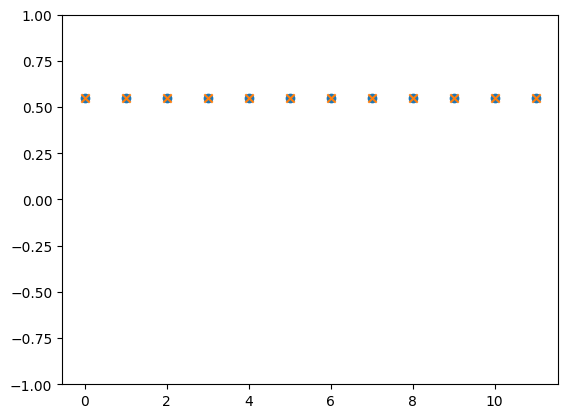

In [ ]:
def expect_single(psi, op, i, N):
    d = op.shape[0]
    psi = psi.reshape([d]*N)
    psi_op = np.tensordot(op, psi, axes=[[1],[i]]) 
    psi_op = np.moveaxis(psi_op, 0, i)
    return np.real(np.dot(psi.conj().reshape(-1), psi_op.reshape(-1)))

def expect_two(psi, op1, op2, i, j, N):
    d = op1.shape[0]
    psi = psi.reshape([d]*N)
    psi_op = np.tensordot(op2, psi, axes=[[1],[j]])
    psi_op = np.moveaxis(psi_op, 0, j)
    psi_op = np.tensordot(op1, psi_op, axes=[[1],[i]])
    psi_op = np.moveaxis(psi_op, 0, i)
    return np.real(np.dot(psi.conj().reshape(-1), psi_op.reshape(-1)))

Z = np.zeros(Nsites)
XX = np.zeros(Nsites)

for i in range(Nsites):
    Z[i] = expect_single(psi[:,0], sZ, i, Nsites)
    XX[i] = expect_two(psi[:,0], sX, sX, i, (i+1)%Nsites, Nsites)

plt.scatter(range(Nsites), Z, marker="o")
plt.scatter(range(Nsites), XX, marker='x')
plt.ylim(-1, 1)

In [ ]:
# build H explicitly as a dense matrix
Hmat = np.zeros((2**Nsites, 2**Nsites), dtype=complex)
for i in range(2**Nsites):
    ei = np.zeros(2**Nsites)
    ei[i] = 1.0
    Hmat[:, i] = doApplyHam(ei, hloc, Nsites, usePBC)

# check hermiticity
print("Hermitian?", np.allclose(Hmat, Hmat.conj().T))

# diagonalize directly
evals, evecs = np.linalg.eigh(Hmat)
print("Ground state energy (dense):", evals[0])
print("Ground state energy (eigsh):", Energy[0])

# check self-duality of the dense H directly
# duality transformation: X_i X_{i+1} <-> Z_i is implemented by
# the unitary that maps Z->XX, X->Z
psi0_dense = evecs[:, 0]
Z_dense = np.array([expect_single(psi0_dense, sZ, i, Nsites) for i in range(Nsites)])
XX_dense = np.array([expect_two(psi0_dense, sX, sX, i, (i+1)%Nsites, Nsites) for i in range(Nsites)])

print("<Z>: ", np.round(Z_dense, 4))
print("<XX>:", np.round(XX_dense, 4))
print("Hermitian?", np.allclose(Hmat, Hmat.conj().T))

Hermitian? True
Ground state energy (dense): -11.342563639235415
Ground state energy (eigsh): -11.342563639235472
<Z>:  [-0.7413 -0.7413 -0.7413 -0.7413 -0.7413 -0.7413 -0.7413 -0.7413 -0.7413]
<XX>: [-0.519 -0.519 -0.519 -0.519 -0.519 -0.519 -0.519 -0.519 -0.519]
Hermitian? True
